# Análise de Resultados — Testes de Carga (Locust)

**Cenários testados:**
- **C1** — GET Imagem 1 MB  
- **C2** — GET Texto 400 KB  
- **C3** — GET Imagem 300 KB  
- **C4** — Carga mista (C1 + C2 + C3)

**Variáveis:**
- Instâncias WordPress: **1, 3, 5**  
- Usuários simultâneos: **200, 600, 1200**


---
## 1. Configuração e Carregamento dos Dados


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import glob
import re
import warnings
warnings.filterwarnings('ignore')

# ── Estilo ──────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8,
})

# ── Paletas ──────────────────────────────────────────────────
SCENARIO_COLORS = {1: '#2196F3', 2: '#4CAF50', 3: '#FF9800', 4: '#9C27B0'}
SCENARIO_LABELS = {1: 'C1: Img 1MB', 2: 'C2: Texto 400KB',
                   3: 'C3: Img 300KB', 4: 'C4: Misto'}
INST_COLORS     = {1: '#1565C0', 3: '#2E7D32', 5: '#BF360C'}
USER_COLORS     = {200: '#4527A0', 600: '#00695C', 1200: '#E65100'}

SCENARIOS = [1, 2, 3, 4]
INSTANCES = [1, 3, 5]
USERS     = [200, 600, 1200]

print('✓ Configurações carregadas.')


✓ Configurações carregadas.


In [13]:
records = []

for path in sorted(glob.glob('resultados/*_stats.csv')):
    if 'history' in path:
        continue
    m = re.search(r'cenario(\d)_(\d+)inst_(\d+)u_stats\.csv', path)
    if not m:
        continue
    cenario, instances, users = int(m.group(1)), int(m.group(2)), int(m.group(3))
    try:
        df = pd.read_csv(path)
        row = df[df['Name'] == 'Aggregated'].iloc[0]
        rc = float(row['Request Count'])
        fc = float(row['Failure Count'])
        records.append({
            'cenario'            : cenario,
            'instances'          : instances,
            'users'              : users,
            'request_count'      : rc,
            'failure_count'      : fc,
            'failure_rate'       : (fc / rc * 100) if rc > 0 else 0,
            'avg_response_time'  : float(row['Average Response Time']),
            'median_response_time': float(row['Median Response Time']),
            'p90'                : float(row['90%']),
            'p95'                : float(row['95%']),
            'p99'                : float(row['99%']),
            'requests_per_s'     : float(row['Requests/s']),
            'failures_per_s'     : float(row['Failures/s']),
            'min_response_time'  : float(row['Min Response Time']),
            'max_response_time'  : float(row['Max Response Time']),
        })
    except Exception as e:
        print(f'⚠ Erro em {path}: {e}')

df_all = (pd.DataFrame(records)
            .sort_values(['cenario', 'instances', 'users'])
            .reset_index(drop=True))

print(f'✓ {len(df_all)} registros carregados')
print(f'  Cenários  : {sorted(df_all["cenario"].unique())}')
print(f'  Instâncias: {sorted(df_all["instances"].unique())}')
print(f'  Usuários  : {sorted(df_all["users"].unique())}')
df_all


✓ 36 registros carregados
  Cenários  : [1, 2, 3, 4]
  Instâncias: [1, 3, 5]
  Usuários  : [200, 600, 1200]


,cenario,instances,users,request_count,failure_count,failure_rate,avg_response_time,median_response_time,p90,p95,p99,requests_per_s,failures_per_s,min_response_time,max_response_time
0,1,1,200,3066.0,0.0,0.000000,94.825025,44.0,220.0,410.0,670.0,97.899195,0.000000,25.300573,774.945683
1,1,1,600,4619.0,0.0,0.000000,2278.926764,2300.0,3700.0,4000.0,4900.0,130.686096,0.000000,32.883996,8747.213353
2,1,1,1200,11348.0,6187.0,54.520620,1798.519836,560.0,4600.0,5300.0,6600.0,269.301804,146.825014,2.029479,8855.115405
3,1,3,200,2416.0,0.0,0.000000,637.247537,42.0,130.0,10000.0,10000.0,77.521777,0.000000,25.431363,10494.774882
4,1,3,600,4572.0,0.0,0.000000,2235.483886,2400.0,3200.0,3400.0,3800.0,129.241527,0.000000,115.628318,4959.433050
5,1,3,1200,11754.0,6544.0,55.674664,1650.067692,230.0,4400.0,4800.0,5600.0,279.062187,155.366935,2.131881,7206.309788
6,1,5,200,1621.0,0.0,0.000000,1871.332312,40.0,480.0,20000.0,25000.0,52.013643,0.000000,25.310519,25519.748521
7,1,5,600,4796.0,0.0,0.000000,2122.327477,2200.0,3300.0,3600.0,4300.0,135.984604,0.000000,30.215437,5084.051627
8,1,5,1200,11563.0,6358.0,54.985730,1696.431236,310.0,4400.0,4900.0,5700.0,275.155899,151.296481,2.232882,7404.337072
9,2,1,200,3021.0,0.0,0.000000,75.375205,43.0,120.0,280.0,620.0,96.976551,0.000000,27.391309,734.749317


---
## 2. Gráficos por Instância
Cada figura resume **todos os cenários e cargas** para um número fixo de instâncias.


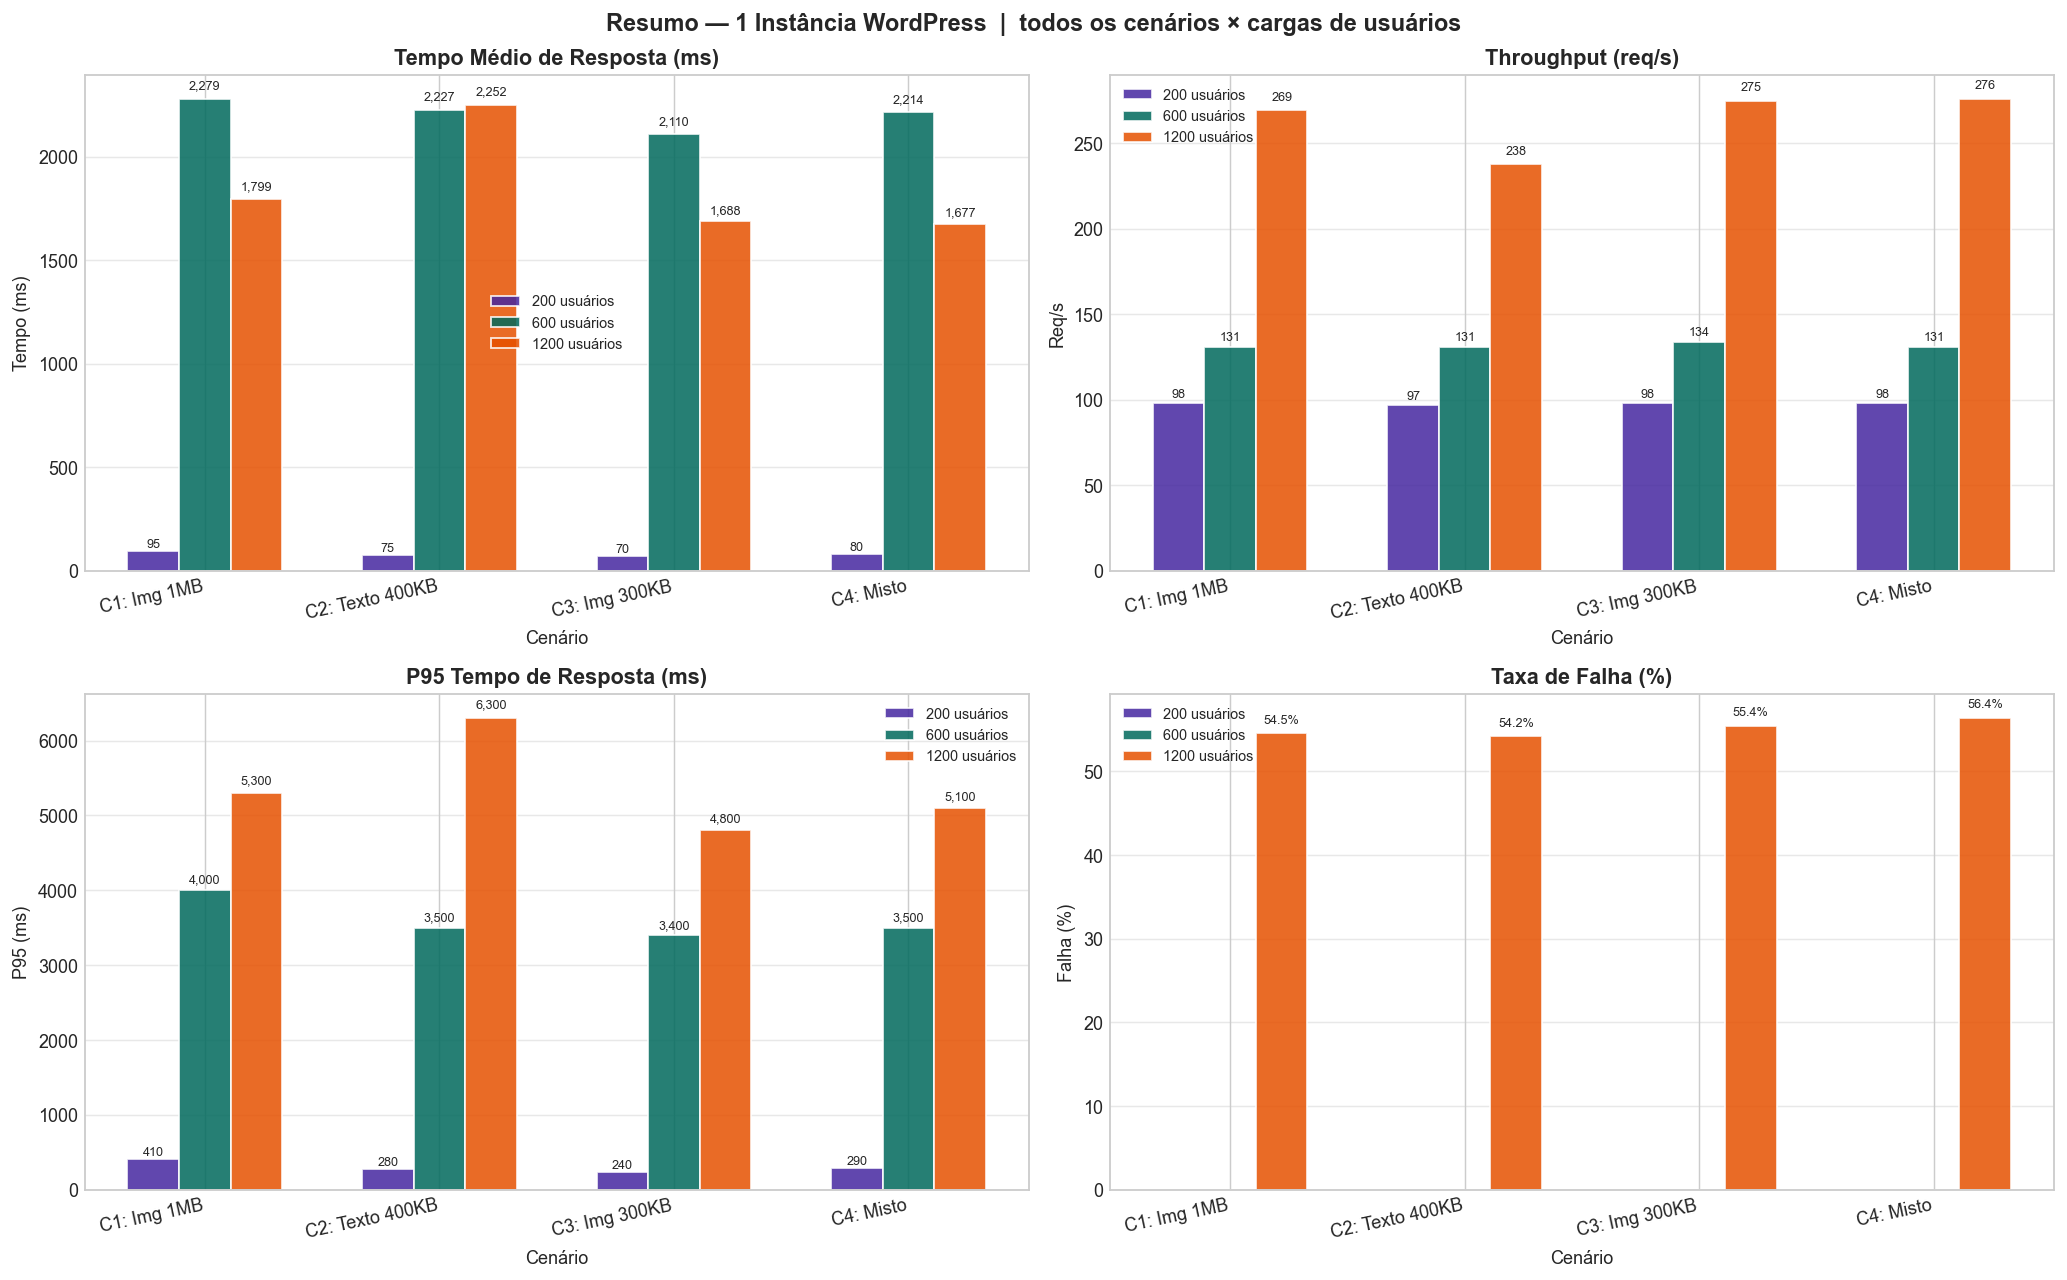

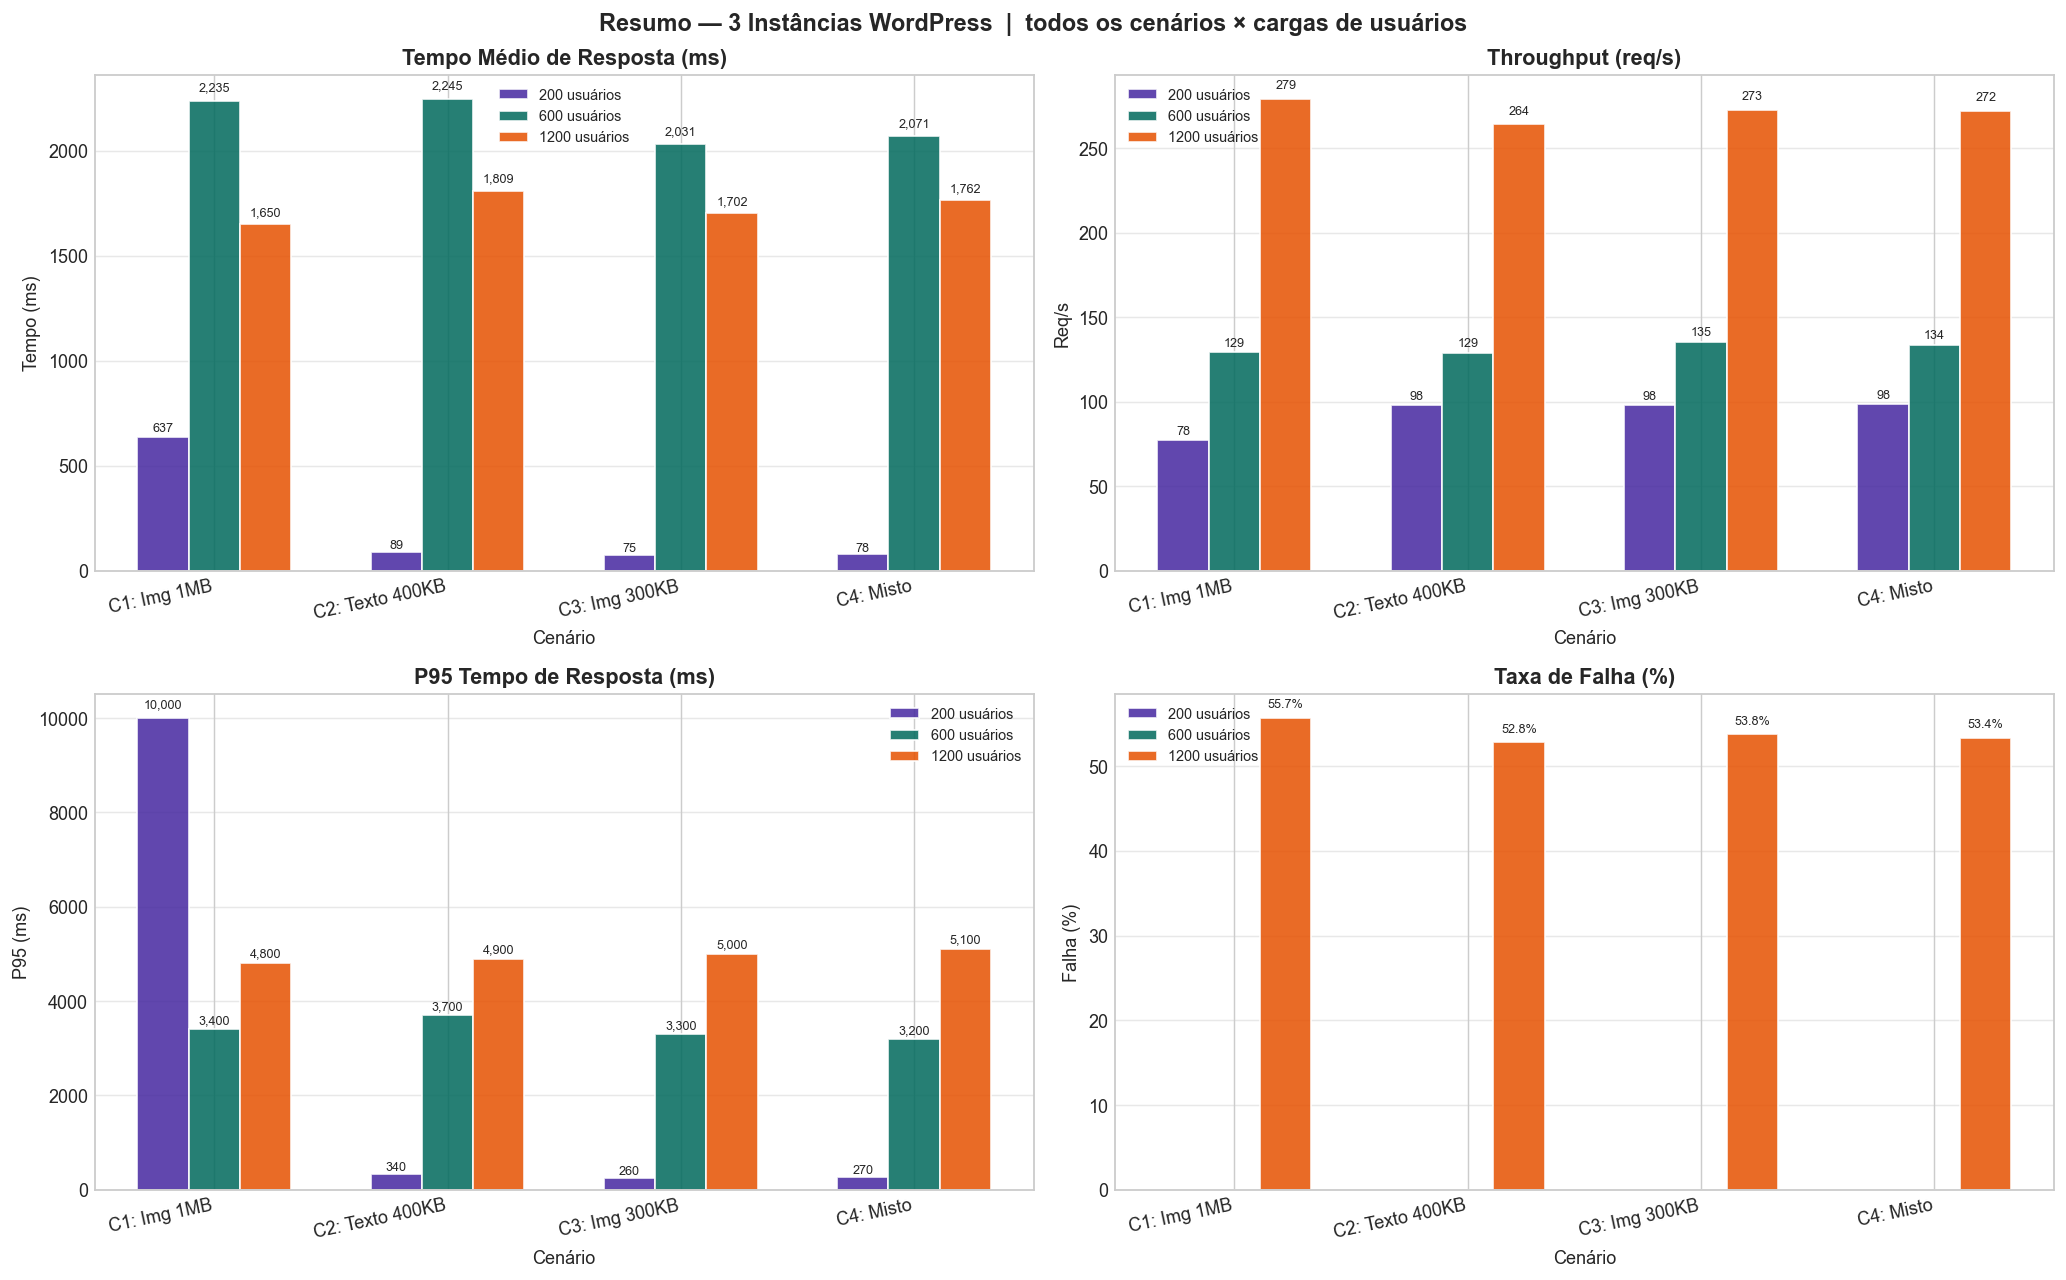

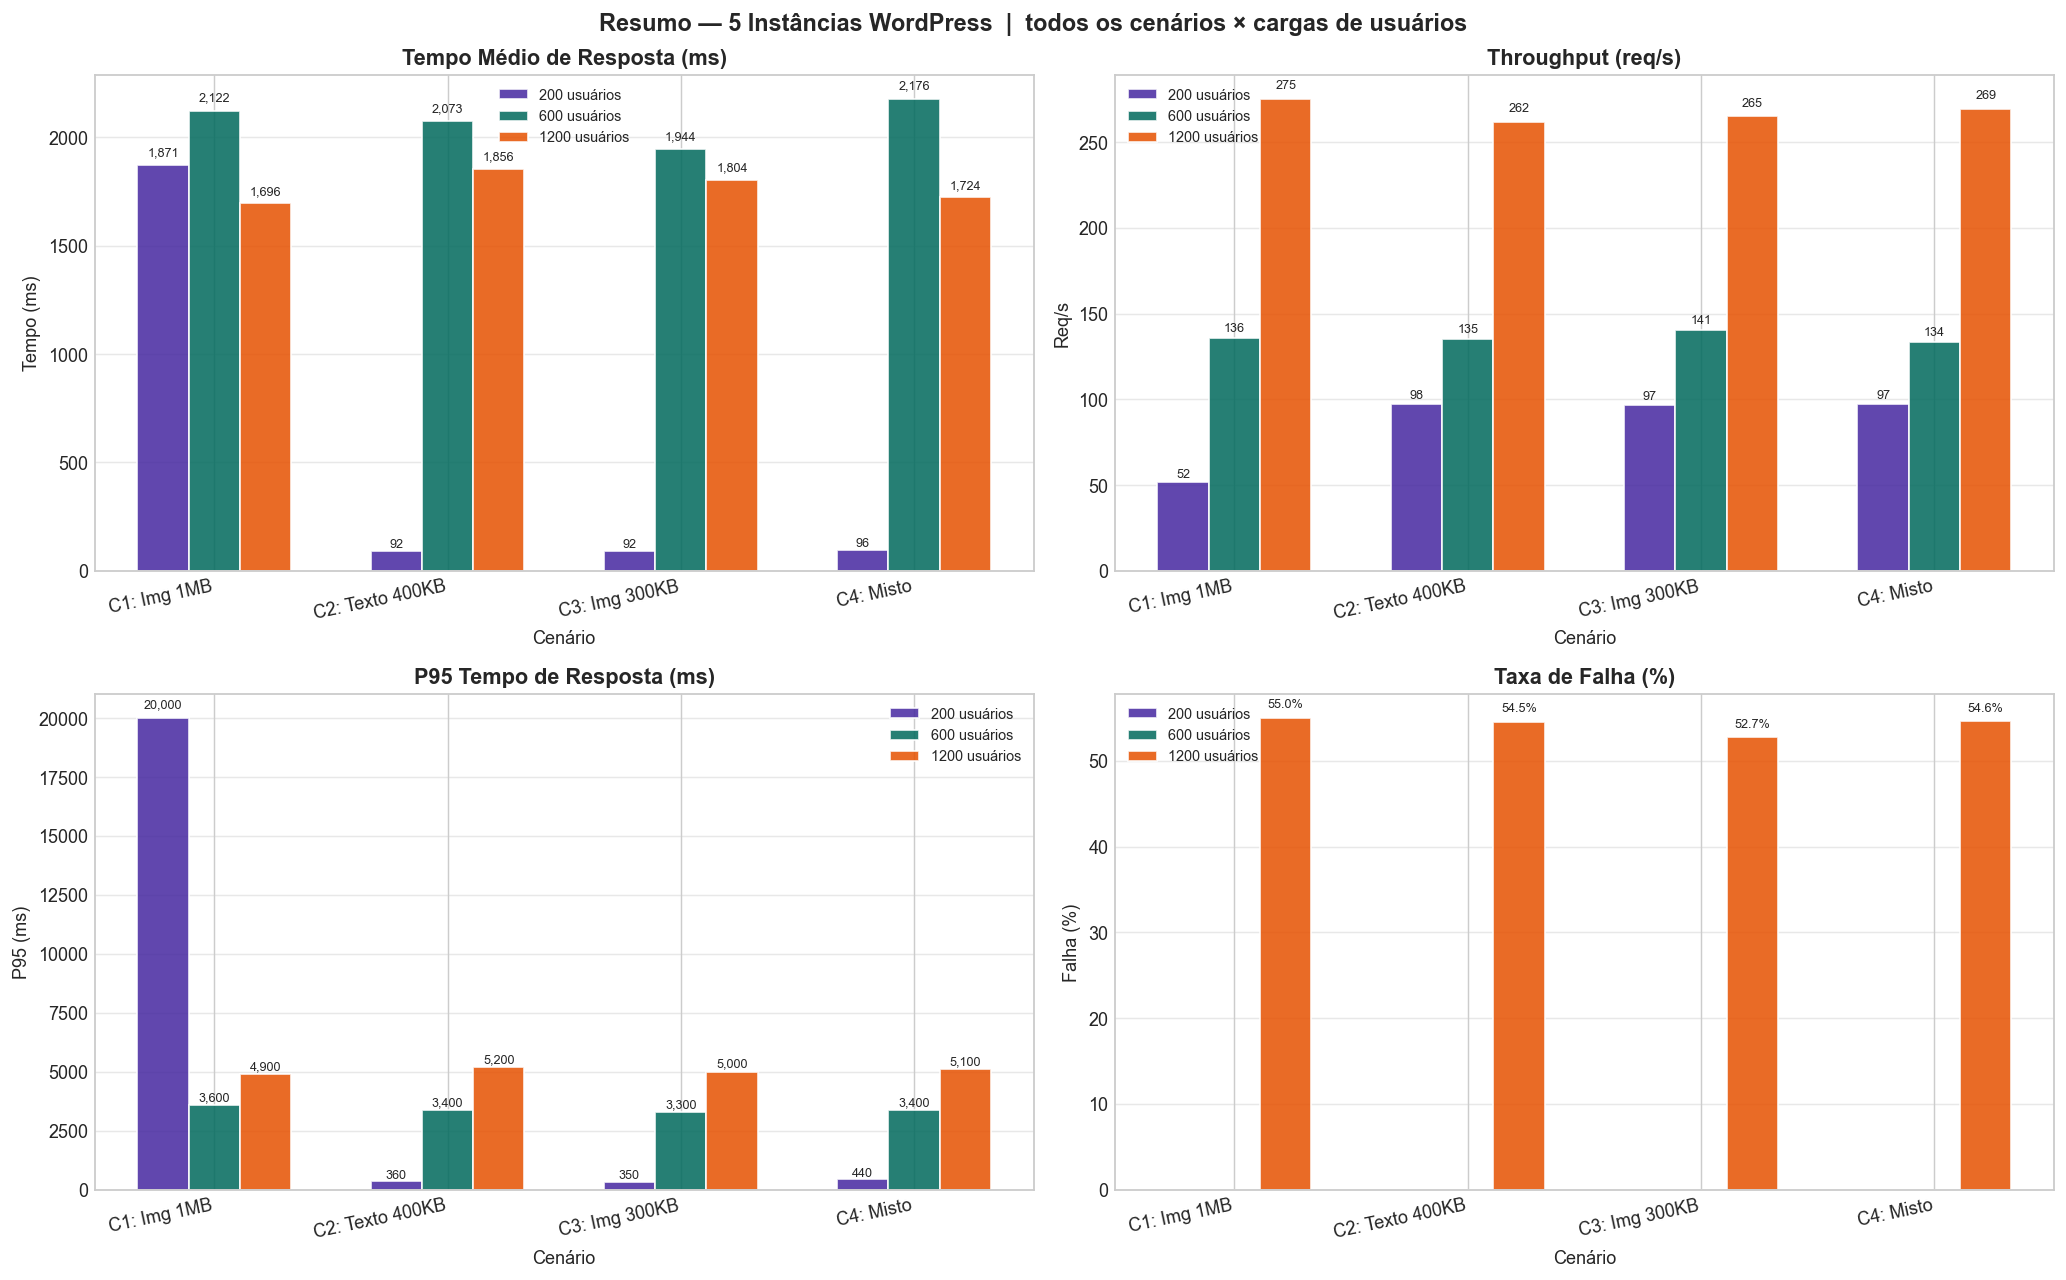

In [14]:
def plot_per_instance(inst_count, df):
    data = df[df['instances'] == inst_count]
    scenarios  = sorted(data['cenario'].unique())
    users_list = sorted(data['users'].unique())
    n_sc, n_u  = len(scenarios), len(users_list)
    x = np.arange(n_sc)
    w = 0.22
    offsets = np.linspace(-(n_u - 1) / 2 * w, (n_u - 1) / 2 * w, n_u)

    metrics = [
        ('avg_response_time',   'Tempo Médio de Resposta (ms)', 'Tempo (ms)'),
        ('requests_per_s',      'Throughput (req/s)',           'Req/s'),
        ('p95',                 'P95 Tempo de Resposta (ms)',   'P95 (ms)'),
        ('failure_rate',        'Taxa de Falha (%)',            'Falha (%)'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plural = 's' if inst_count > 1 else ''
    fig.suptitle(
        f'Resumo — {inst_count} Instância{plural} WordPress'
        f'  |  todos os cenários × cargas de usuários',
        fontsize=13, fontweight='bold'
    )

    for ax, (metric, title, ylabel) in zip(axes.flat, metrics):
        for i, (u, off) in enumerate(zip(users_list, offsets)):
            vals = [
                data[(data['cenario'] == sc) & (data['users'] == u)][metric].values[0]
                if len(data[(data['cenario'] == sc) & (data['users'] == u)]) > 0 else 0
                for sc in scenarios
            ]
            color = list(USER_COLORS.values())[i]
            bars = ax.bar(x + off, vals, w, label=f'{u} usuários',
                          color=color, alpha=0.85, edgecolor='white')
            for bar, val in zip(bars, vals):
                if val > 0:
                    lbl = f'{val:.1f}%' if metric == 'failure_rate' else f'{val:,.0f}'
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.015,
                        lbl, ha='center', va='bottom', fontsize=7
                    )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Cenário')
        ax.set_xticks(x)
        ax.set_xticklabels([SCENARIO_LABELS[sc] for sc in scenarios], rotation=12, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.45)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(f'resultados/grafico_inst{inst_count}.png', bbox_inches='tight', dpi=130)
    plt.show()


for inst in INSTANCES:
    plot_per_instance(inst, df_all)


---
## 3. Gráficos por Número de Usuários
Cada figura resume **todos os cenários e contagens de instâncias** para uma carga fixa.


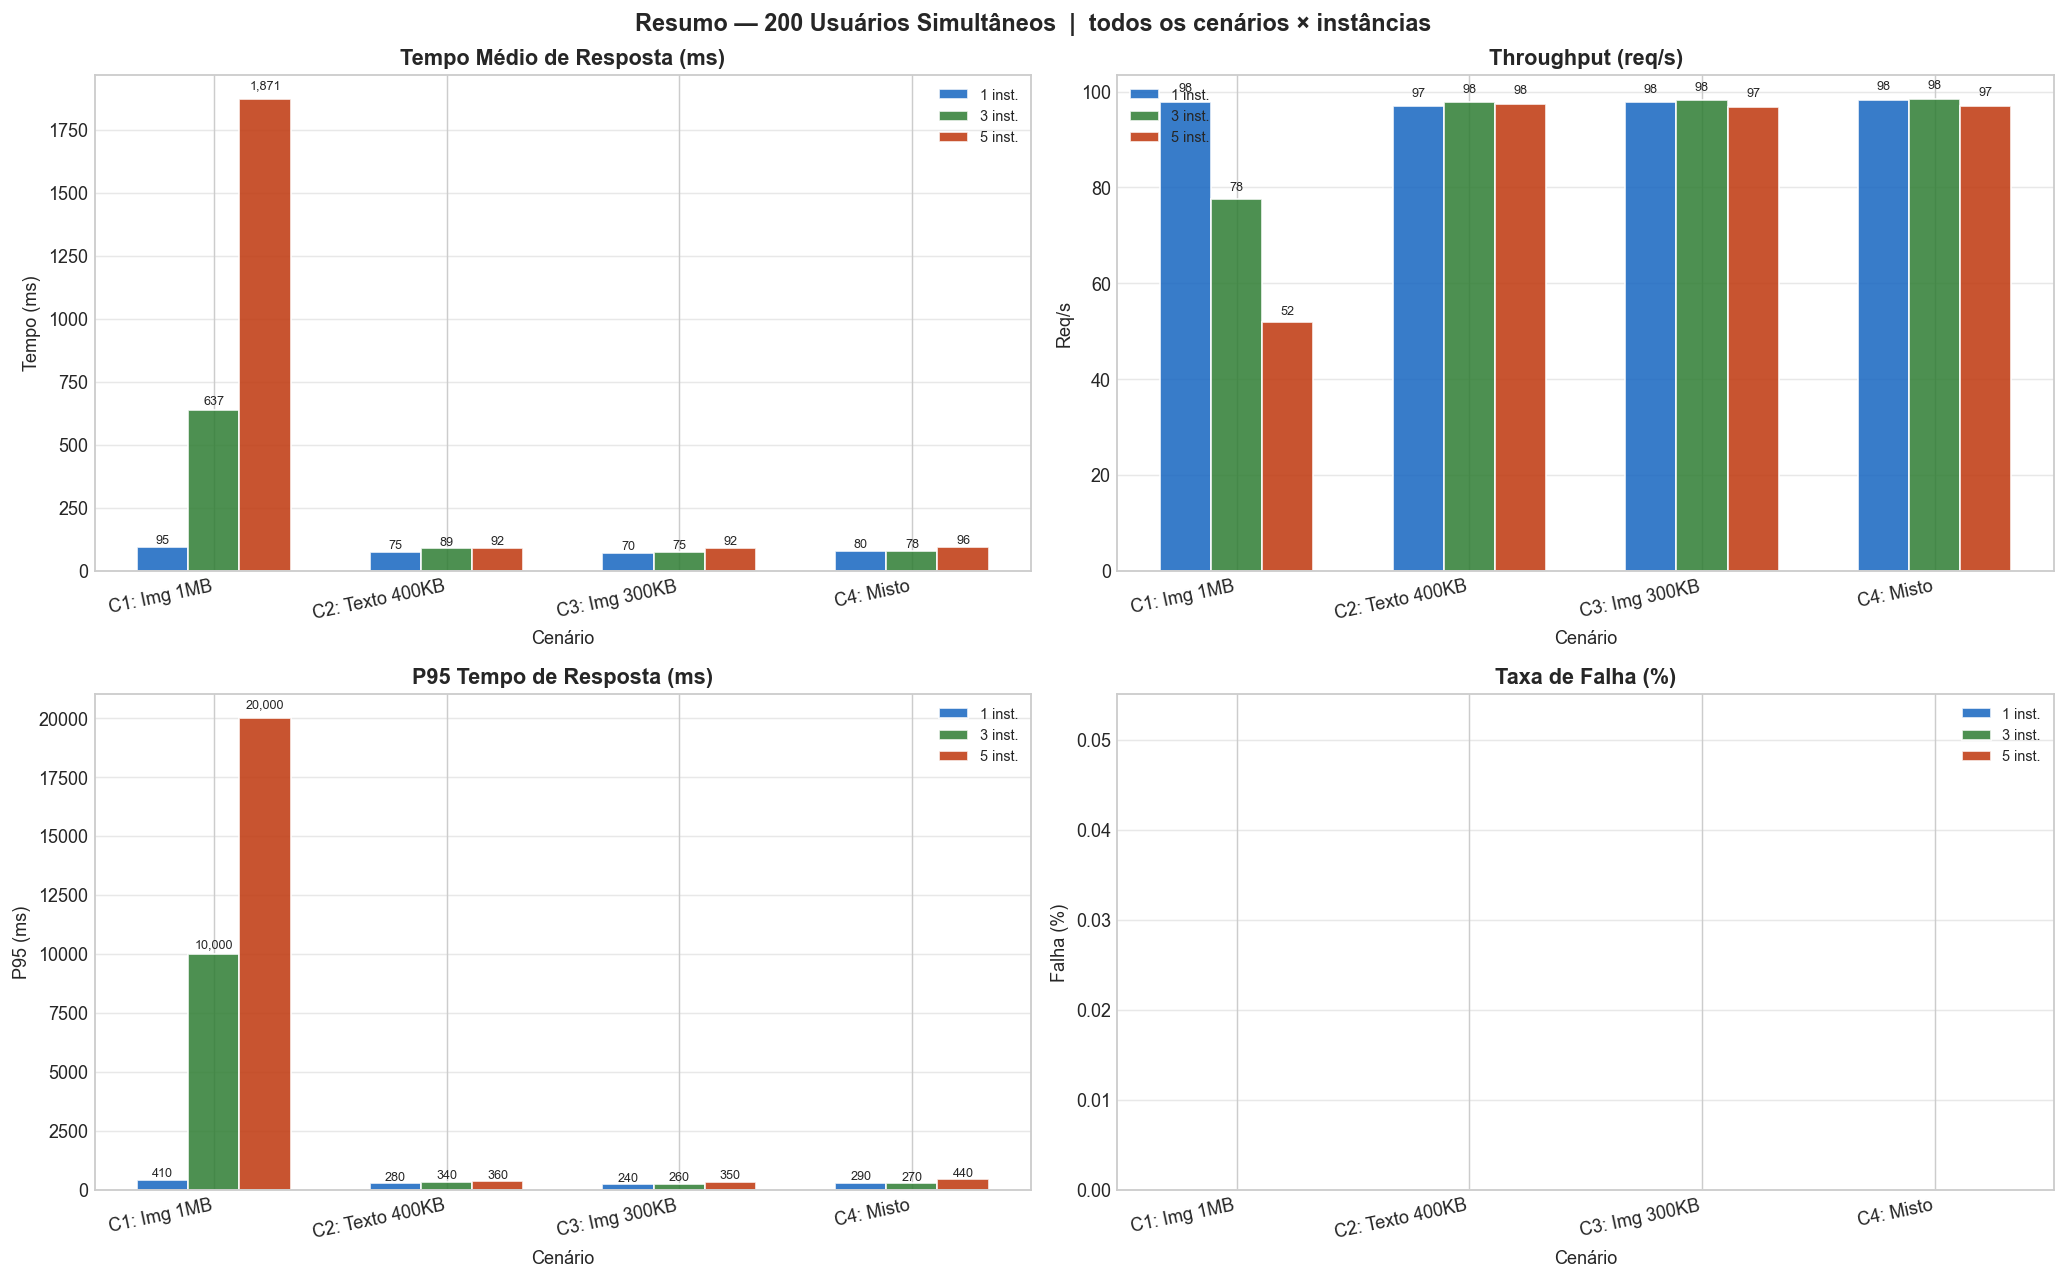

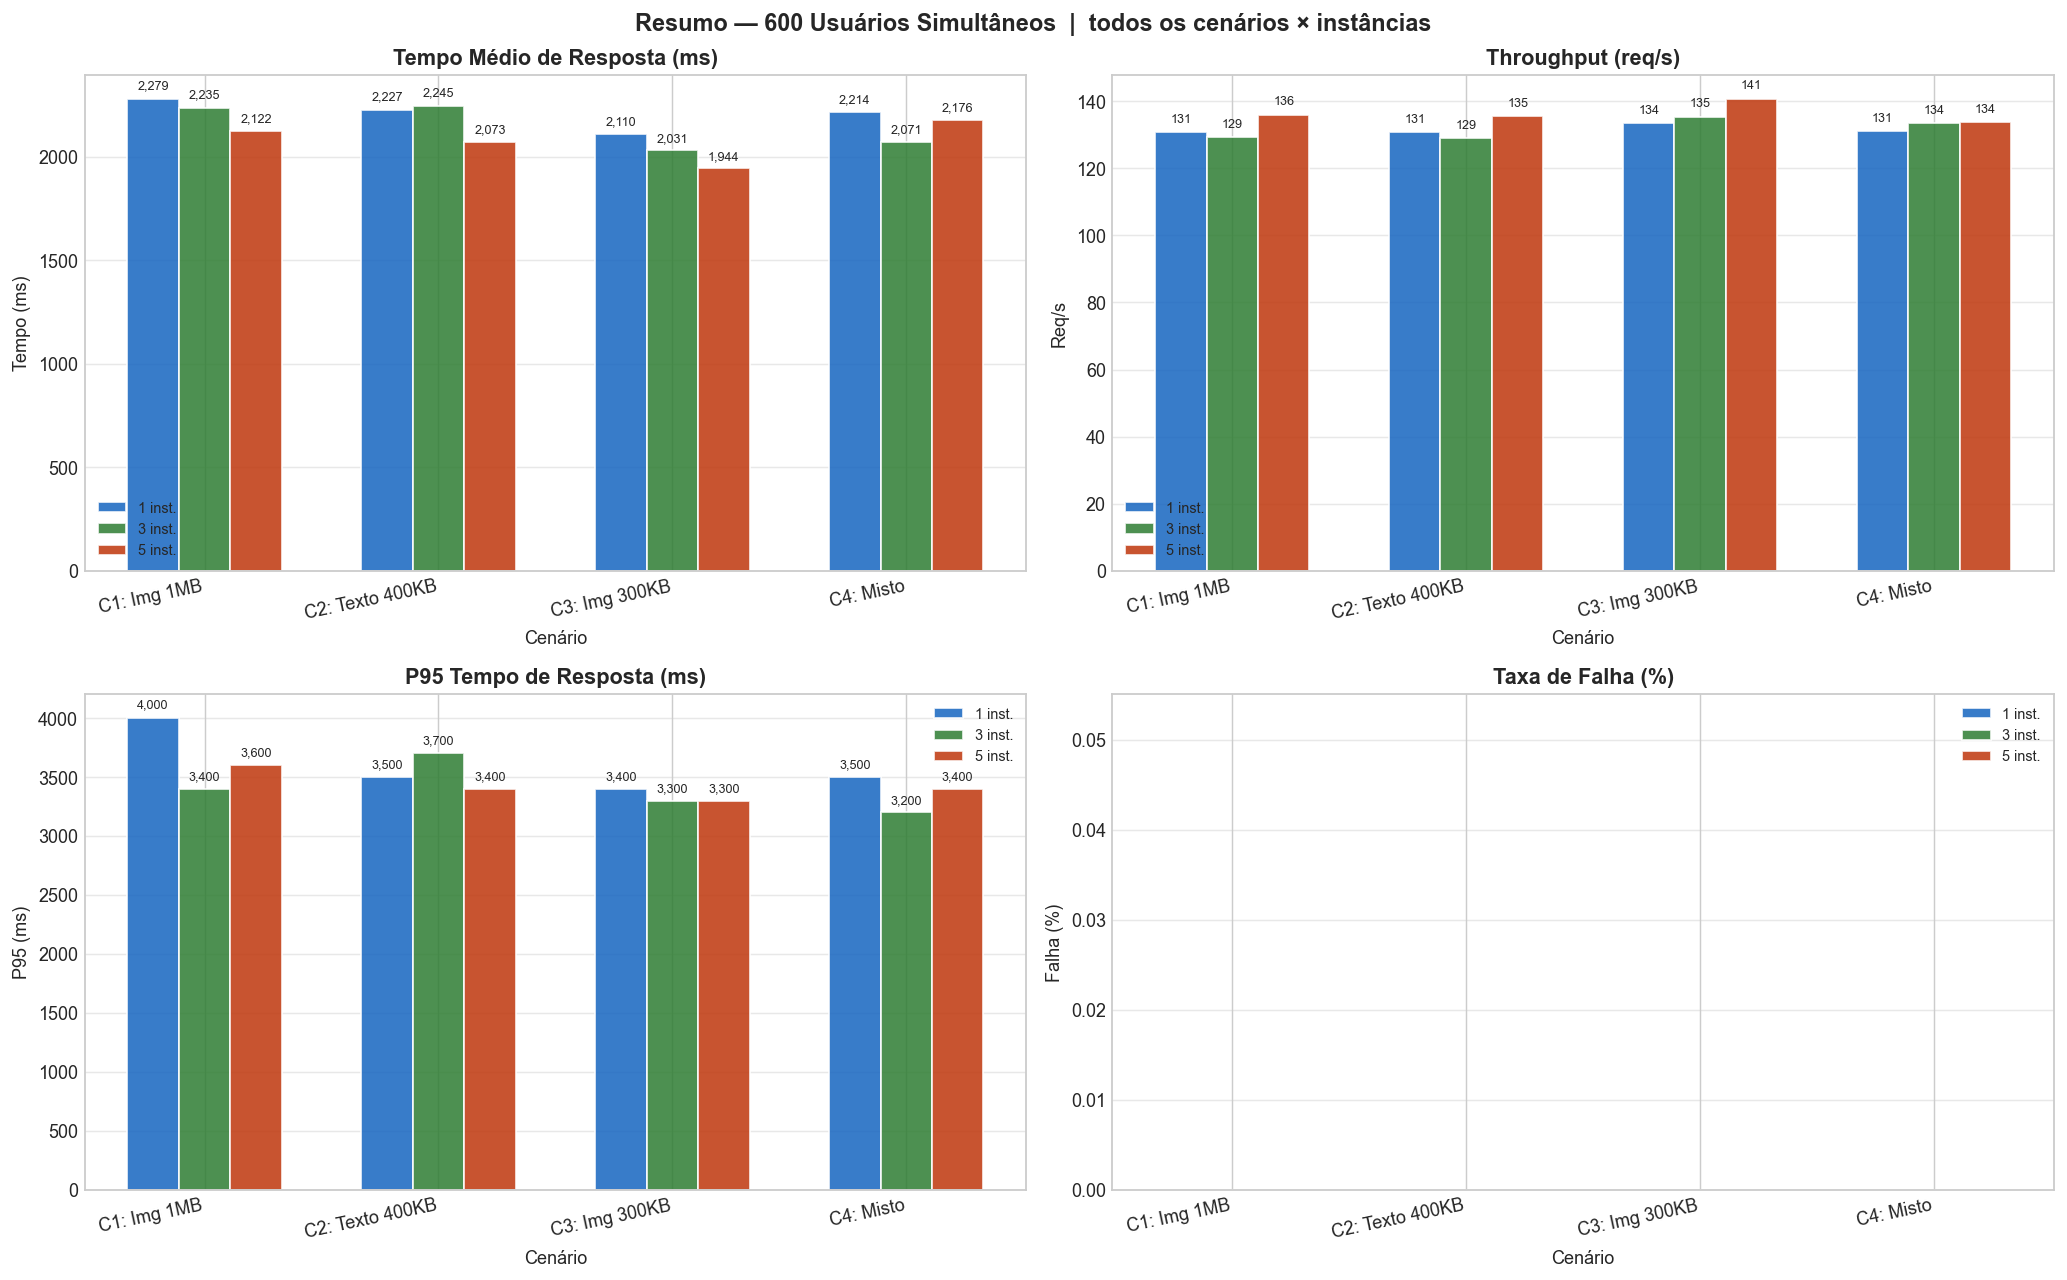

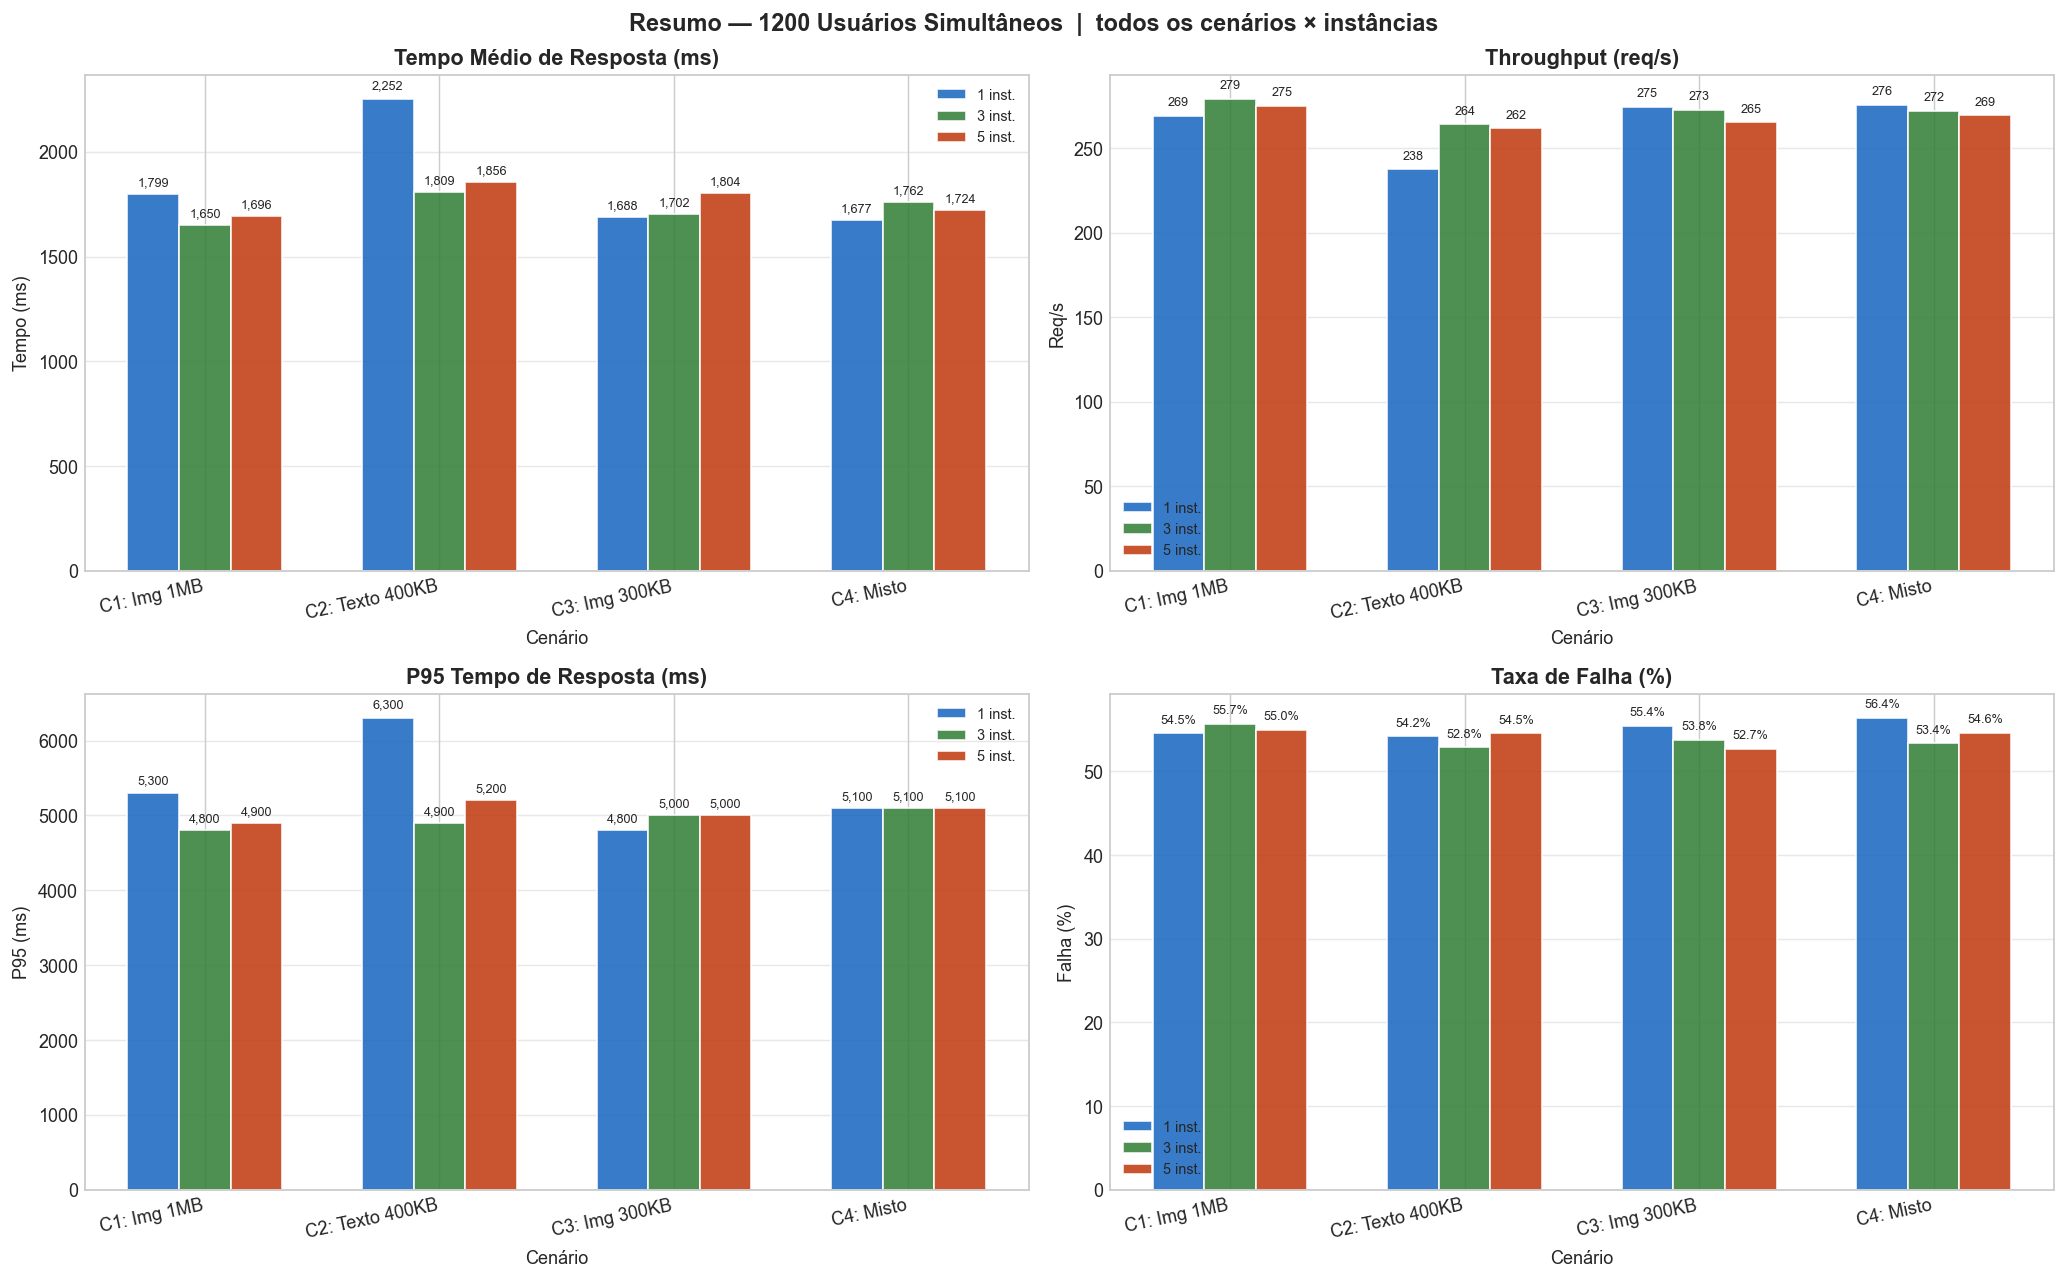

In [15]:
def plot_per_users(user_count, df):
    data = df[df['users'] == user_count]
    scenarios  = sorted(data['cenario'].unique())
    inst_list  = sorted(data['instances'].unique())
    n_sc, n_i  = len(scenarios), len(inst_list)
    x = np.arange(n_sc)
    w = 0.22
    offsets = np.linspace(-(n_i - 1) / 2 * w, (n_i - 1) / 2 * w, n_i)

    metrics = [
        ('avg_response_time',   'Tempo Médio de Resposta (ms)', 'Tempo (ms)'),
        ('requests_per_s',      'Throughput (req/s)',           'Req/s'),
        ('p95',                 'P95 Tempo de Resposta (ms)',   'P95 (ms)'),
        ('failure_rate',        'Taxa de Falha (%)',            'Falha (%)'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        f'Resumo — {user_count} Usuários Simultâneos'
        f'  |  todos os cenários × instâncias',
        fontsize=13, fontweight='bold'
    )

    for ax, (metric, title, ylabel) in zip(axes.flat, metrics):
        for i, (inst, off) in enumerate(zip(inst_list, offsets)):
            vals = [
                data[(data['cenario'] == sc) & (data['instances'] == inst)][metric].values[0]
                if len(data[(data['cenario'] == sc) & (data['instances'] == inst)]) > 0 else 0
                for sc in scenarios
            ]
            color = list(INST_COLORS.values())[i]
            bars = ax.bar(x + off, vals, w, label=f'{inst} inst.',
                          color=color, alpha=0.85, edgecolor='white')
            for bar, val in zip(bars, vals):
                if val > 0:
                    lbl = f'{val:.1f}%' if metric == 'failure_rate' else f'{val:,.0f}'
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.015,
                        lbl, ha='center', va='bottom', fontsize=7
                    )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Cenário')
        ax.set_xticks(x)
        ax.set_xticklabels([SCENARIO_LABELS[sc] for sc in scenarios], rotation=12, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.45)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(f'resultados/grafico_users{user_count}.png', bbox_inches='tight', dpi=130)
    plt.show()


for users in USERS:
    plot_per_users(users, df_all)


---
## 4. Taxa de Falha
Relação entre **total de requisições** e **percentual de falhas** em todas as combinações testadas.


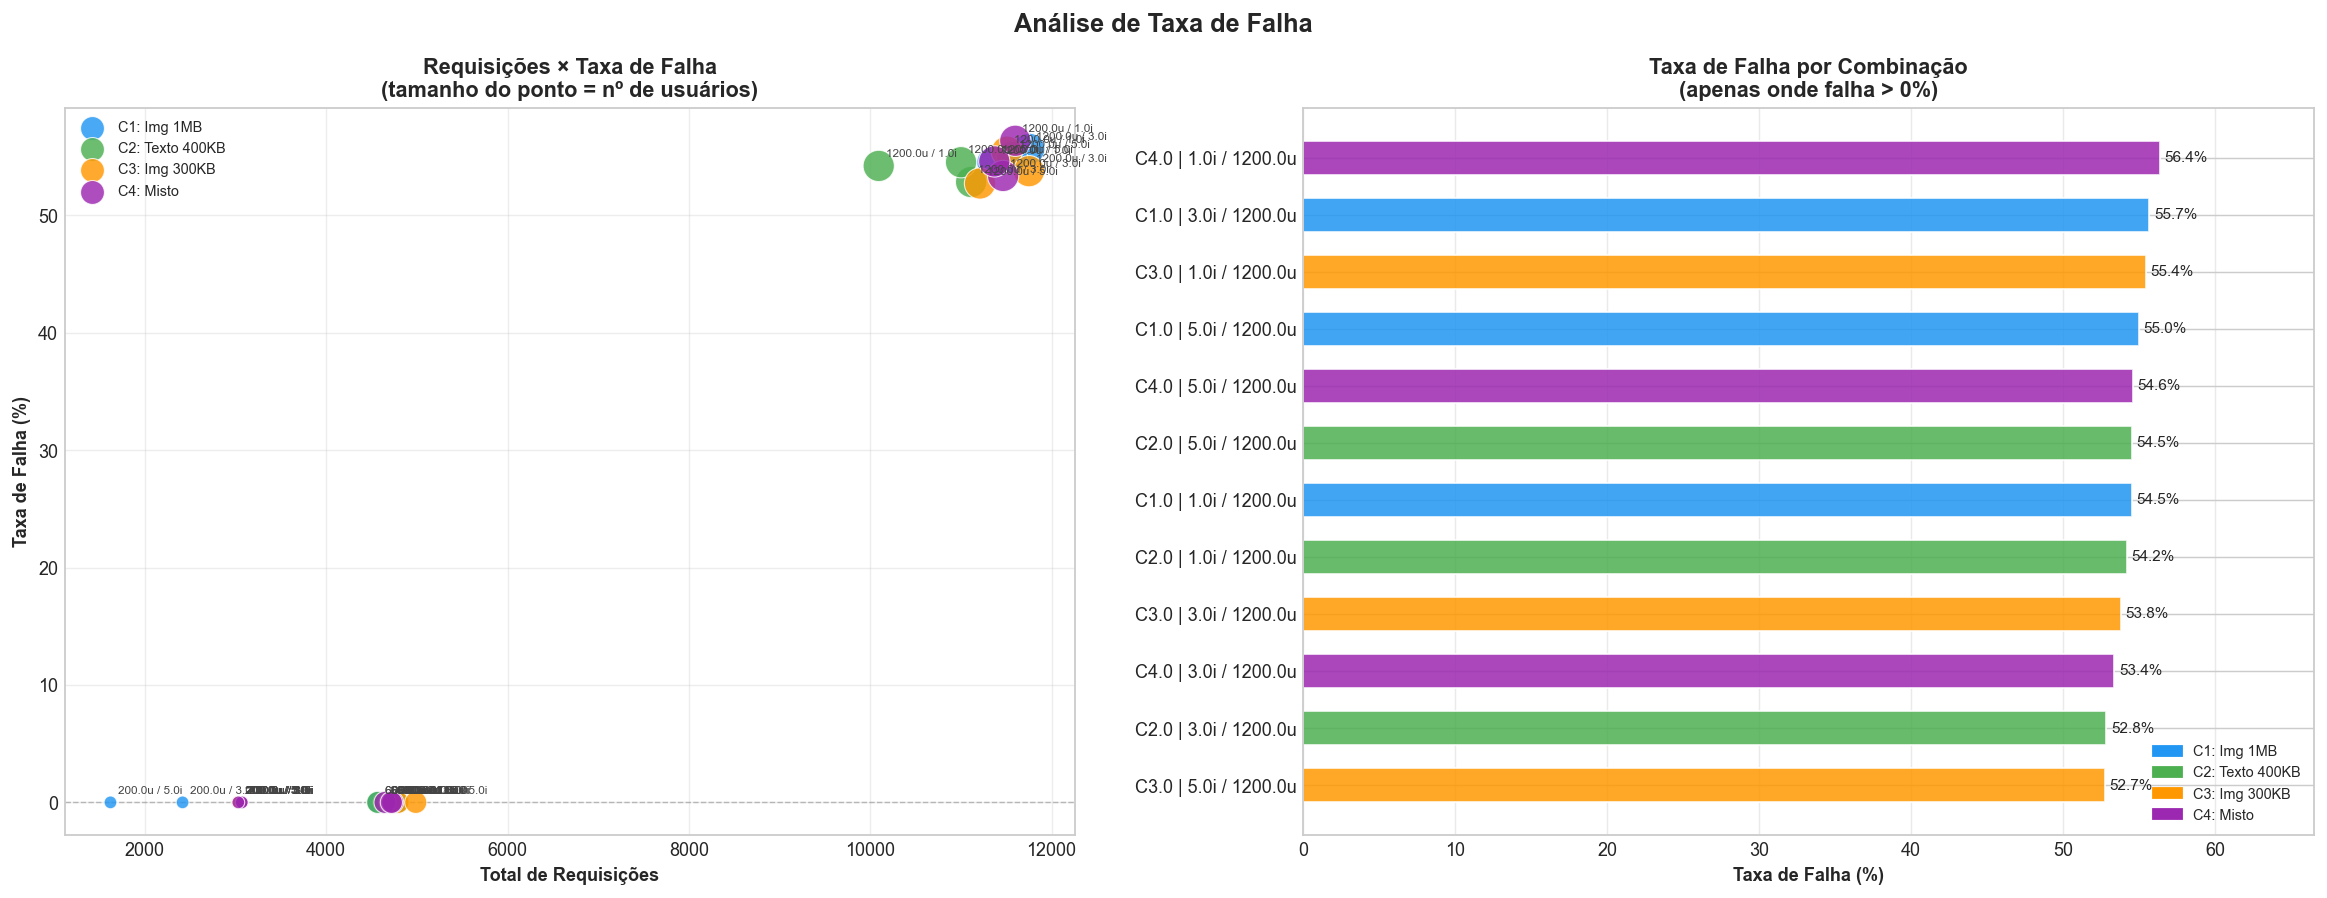

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análise de Taxa de Falha', fontsize=14, fontweight='bold')

# ── Scatter: Total de Requisições × Taxa de Falha ───────────
ax = axes[0]
for sc in SCENARIOS:
    sub = df_all[df_all['cenario'] == sc]
    ax.scatter(
        sub['request_count'], sub['failure_rate'],
        c=SCENARIO_COLORS[sc], label=SCENARIO_LABELS[sc],
        s=sub['users'] / 4,
        alpha=0.82, edgecolors='white', linewidth=0.6, zorder=3
    )

for _, r in df_all.iterrows():
    ax.annotate(
        f"{r['users']}u / {r['instances']}i",
        (r['request_count'], r['failure_rate']),
        xytext=(4, 5), textcoords='offset points',
        fontsize=6.5, color='#444'
    )

ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.set_xlabel('Total de Requisições', fontweight='bold')
ax.set_ylabel('Taxa de Falha (%)', fontweight='bold')
ax.set_title('Requisições × Taxa de Falha\n(tamanho do ponto = nº de usuários)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.35)

# ── Barras horizontais: só combinações com falha > 0 ─────────
ax2 = axes[1]
df_fail = df_all[df_all['failure_rate'] > 0].copy()

if df_fail.empty:
    ax2.text(0.5, 0.5, 'Nenhuma falha registrada!',
             ha='center', va='center', transform=ax2.transAxes, fontsize=13)
else:
    df_fail['label'] = df_fail.apply(
        lambda r: f"C{r['cenario']} | {r['instances']}i / {r['users']}u", axis=1
    )
    df_fail = df_fail.sort_values('failure_rate', ascending=True)
    colors_bar = [SCENARIO_COLORS[c] for c in df_fail['cenario']]

    bars = ax2.barh(df_fail['label'], df_fail['failure_rate'],
                    color=colors_bar, alpha=0.85, edgecolor='white', height=0.6)
    for bar, val in zip(bars, df_fail['failure_rate']):
        ax2.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8.5
        )

    ax2.set_xlabel('Taxa de Falha (%)', fontweight='bold')
    ax2.set_xlim(right=df_fail['failure_rate'].max() * 1.18)
    ax2.grid(axis='x', alpha=0.4)

    # Legenda manual de cenários
    from matplotlib.patches import Patch
    handles = [Patch(color=SCENARIO_COLORS[sc], label=SCENARIO_LABELS[sc]) for sc in SCENARIOS]
    ax2.legend(handles=handles, loc='lower right')

ax2.set_title('Taxa de Falha por Combinação\n(apenas onde falha > 0%)', fontweight='bold')

plt.tight_layout()
plt.savefig('resultados/grafico_taxa_falha.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 5. Geralzão — Impacto do Número de Instâncias
Visão consolidada de como escalar de **1 → 3 → 5 instâncias** afeta todas as métricas,  
agregando todos os cenários e cargas de usuários.


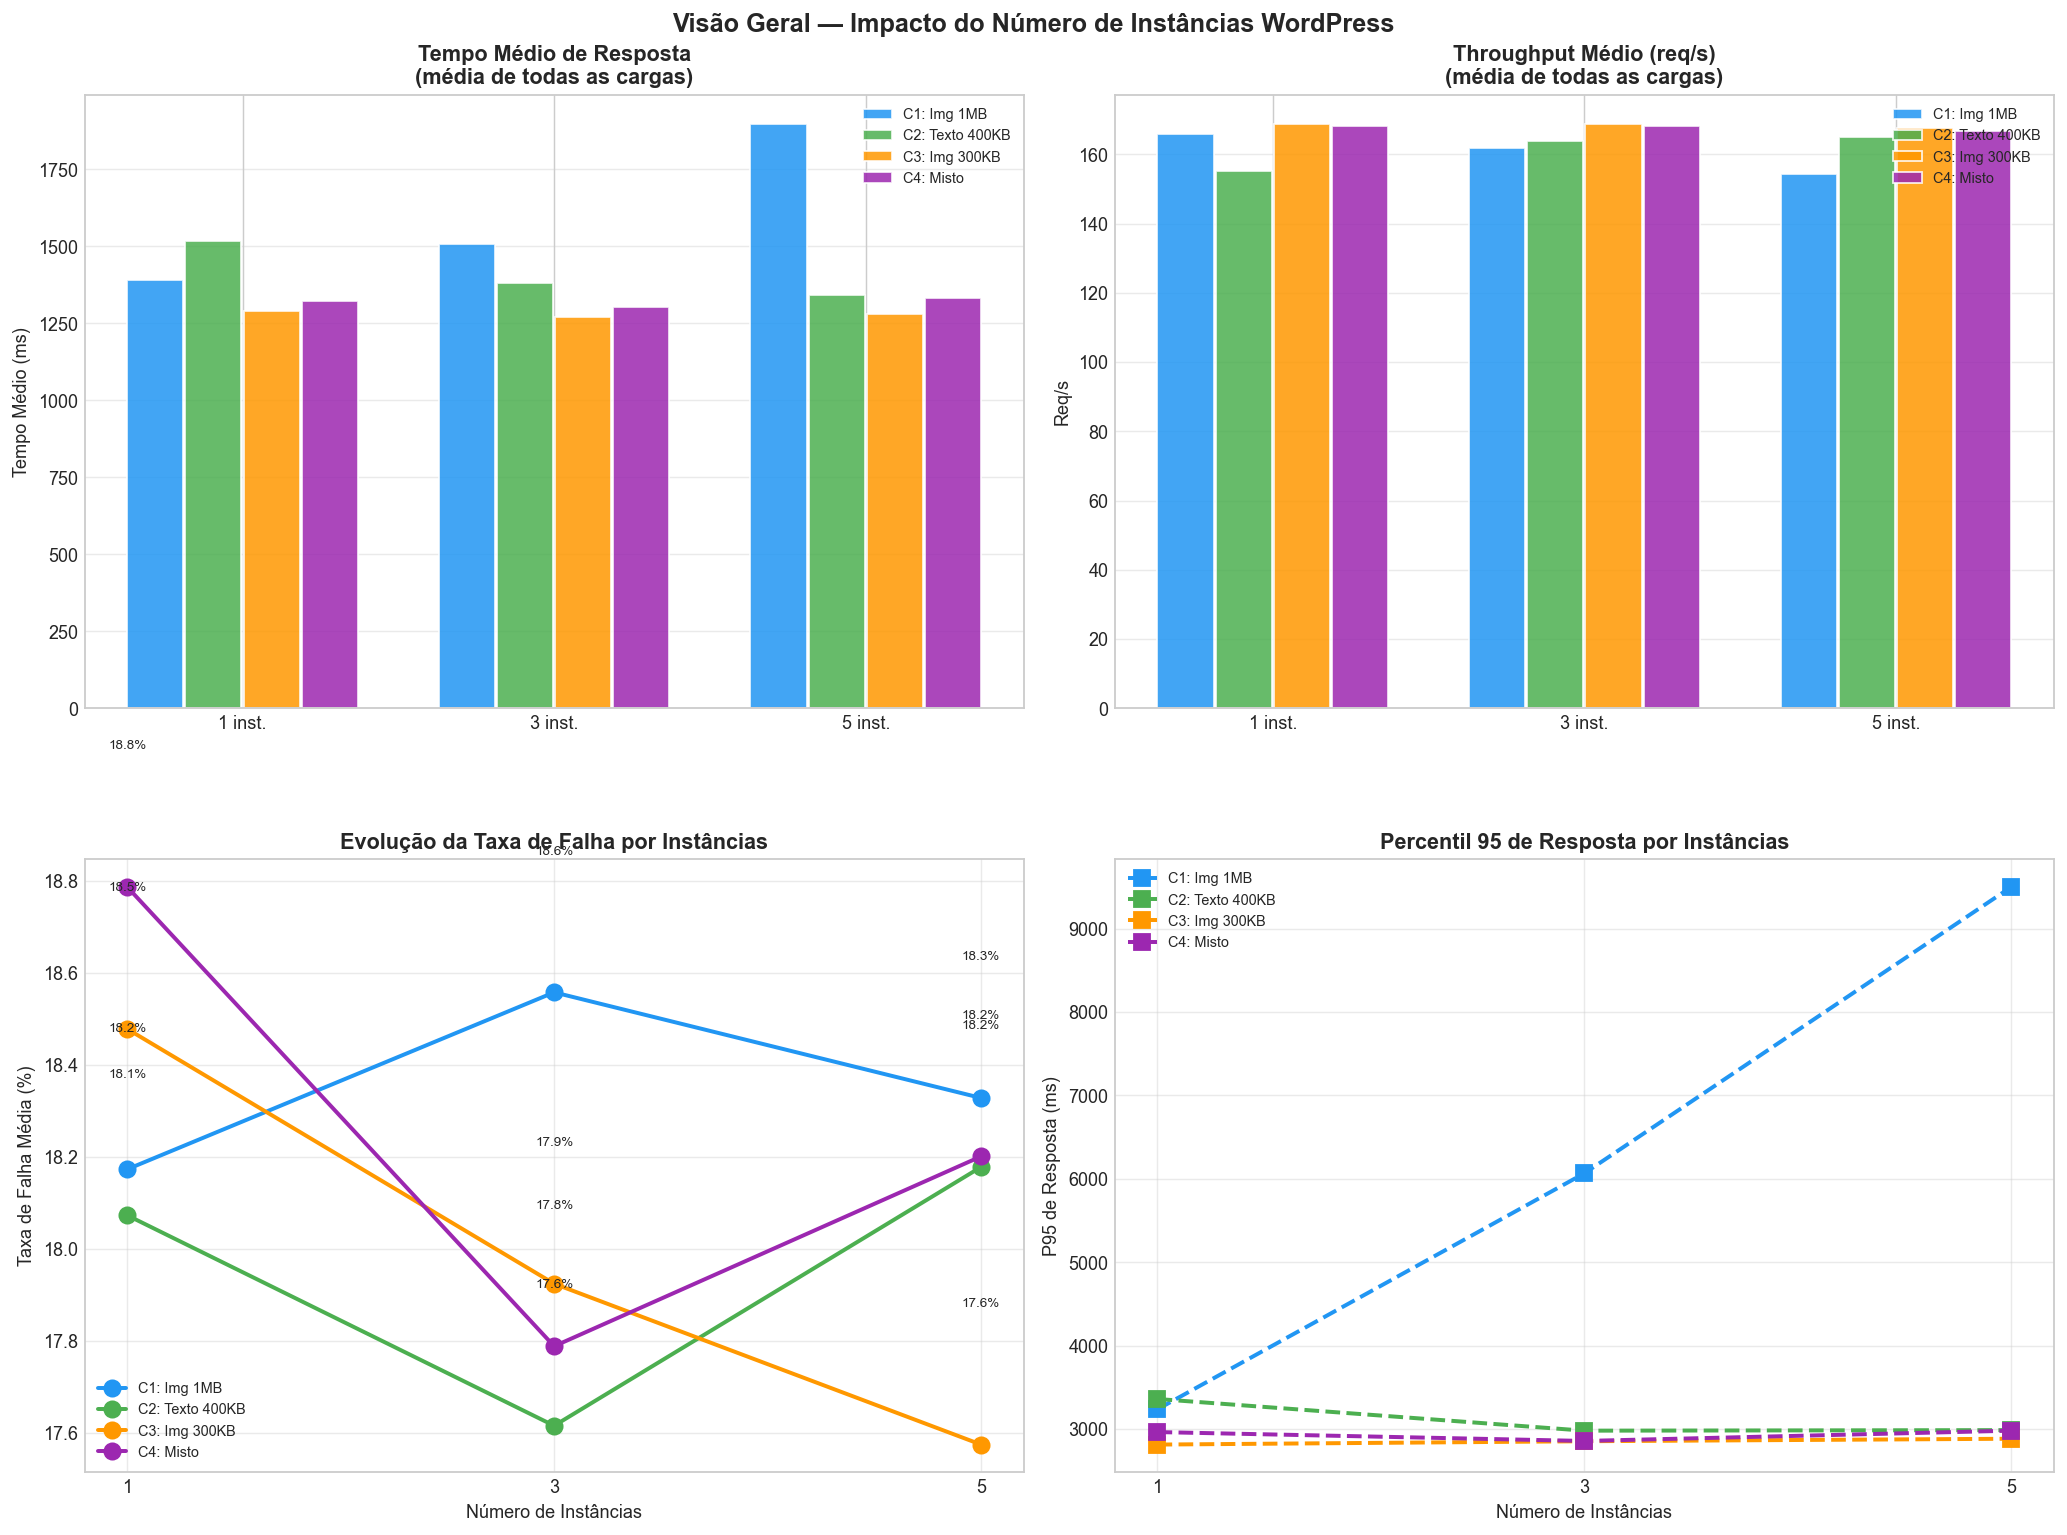

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visão Geral — Impacto do Número de Instâncias WordPress',
             fontsize=14, fontweight='bold')

x_inst  = np.arange(len(INSTANCES))
w       = 0.18
offsets = np.linspace(-0.28, 0.28, len(SCENARIOS))

def inst_agg(sc, inst, metric):
    s = df_all[(df_all['cenario'] == sc) & (df_all['instances'] == inst)]
    return s[metric].mean() if len(s) > 0 else 0

# (0,0) — Tempo médio de resposta
ax = axes[0, 0]
for sc, off in zip(SCENARIOS, offsets):
    vals = [inst_agg(sc, i, 'avg_response_time') for i in INSTANCES]
    ax.bar(x_inst + off, vals, w, label=SCENARIO_LABELS[sc],
           color=SCENARIO_COLORS[sc], alpha=0.85, edgecolor='white')
ax.set_xticks(x_inst)
ax.set_xticklabels([f'{i} inst.' for i in INSTANCES])
ax.set_ylabel('Tempo Médio (ms)')
ax.set_title('Tempo Médio de Resposta\n(média de todas as cargas)')
ax.legend(); ax.grid(axis='y', alpha=0.4); ax.set_ylim(bottom=0)

# (0,1) — Throughput
ax = axes[0, 1]
for sc, off in zip(SCENARIOS, offsets):
    vals = [inst_agg(sc, i, 'requests_per_s') for i in INSTANCES]
    ax.bar(x_inst + off, vals, w, label=SCENARIO_LABELS[sc],
           color=SCENARIO_COLORS[sc], alpha=0.85, edgecolor='white')
ax.set_xticks(x_inst)
ax.set_xticklabels([f'{i} inst.' for i in INSTANCES])
ax.set_ylabel('Req/s')
ax.set_title('Throughput Médio (req/s)\n(média de todas as cargas)')
ax.legend(); ax.grid(axis='y', alpha=0.4); ax.set_ylim(bottom=0)

# (1,0) — Taxa de falha (linha)
ax = axes[1, 0]
for sc in SCENARIOS:
    vals = [inst_agg(sc, i, 'failure_rate') for i in INSTANCES]
    ax.plot(INSTANCES, vals, 'o-', label=SCENARIO_LABELS[sc],
            color=SCENARIO_COLORS[sc], linewidth=2.2, markersize=9)
    for xi, yi in zip(INSTANCES, vals):
        ax.text(xi, yi + 0.3, f'{yi:.1f}%', ha='center', fontsize=7.5)
ax.set_xticks(INSTANCES)
ax.set_xlabel('Número de Instâncias')
ax.set_ylabel('Taxa de Falha Média (%)')
ax.set_title('Evolução da Taxa de Falha por Instâncias')
ax.legend(); ax.grid(alpha=0.4)

# (1,1) — P95 (linha)
ax = axes[1, 1]
for sc in SCENARIOS:
    vals = [inst_agg(sc, i, 'p95') for i in INSTANCES]
    ax.plot(INSTANCES, vals, 's--', label=SCENARIO_LABELS[sc],
            color=SCENARIO_COLORS[sc], linewidth=2.2, markersize=9)
ax.set_xticks(INSTANCES)
ax.set_xlabel('Número de Instâncias')
ax.set_ylabel('P95 de Resposta (ms)')
ax.set_title('Percentil 95 de Resposta por Instâncias')
ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('resultados/grafico_geralzao_instancias.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 6. Geralzão — Impacto do Número de Usuários
Visão consolidada de como escalar de **200 → 600 → 1200 usuários** afeta todas as métricas,  
agregando todos os cenários e instâncias.


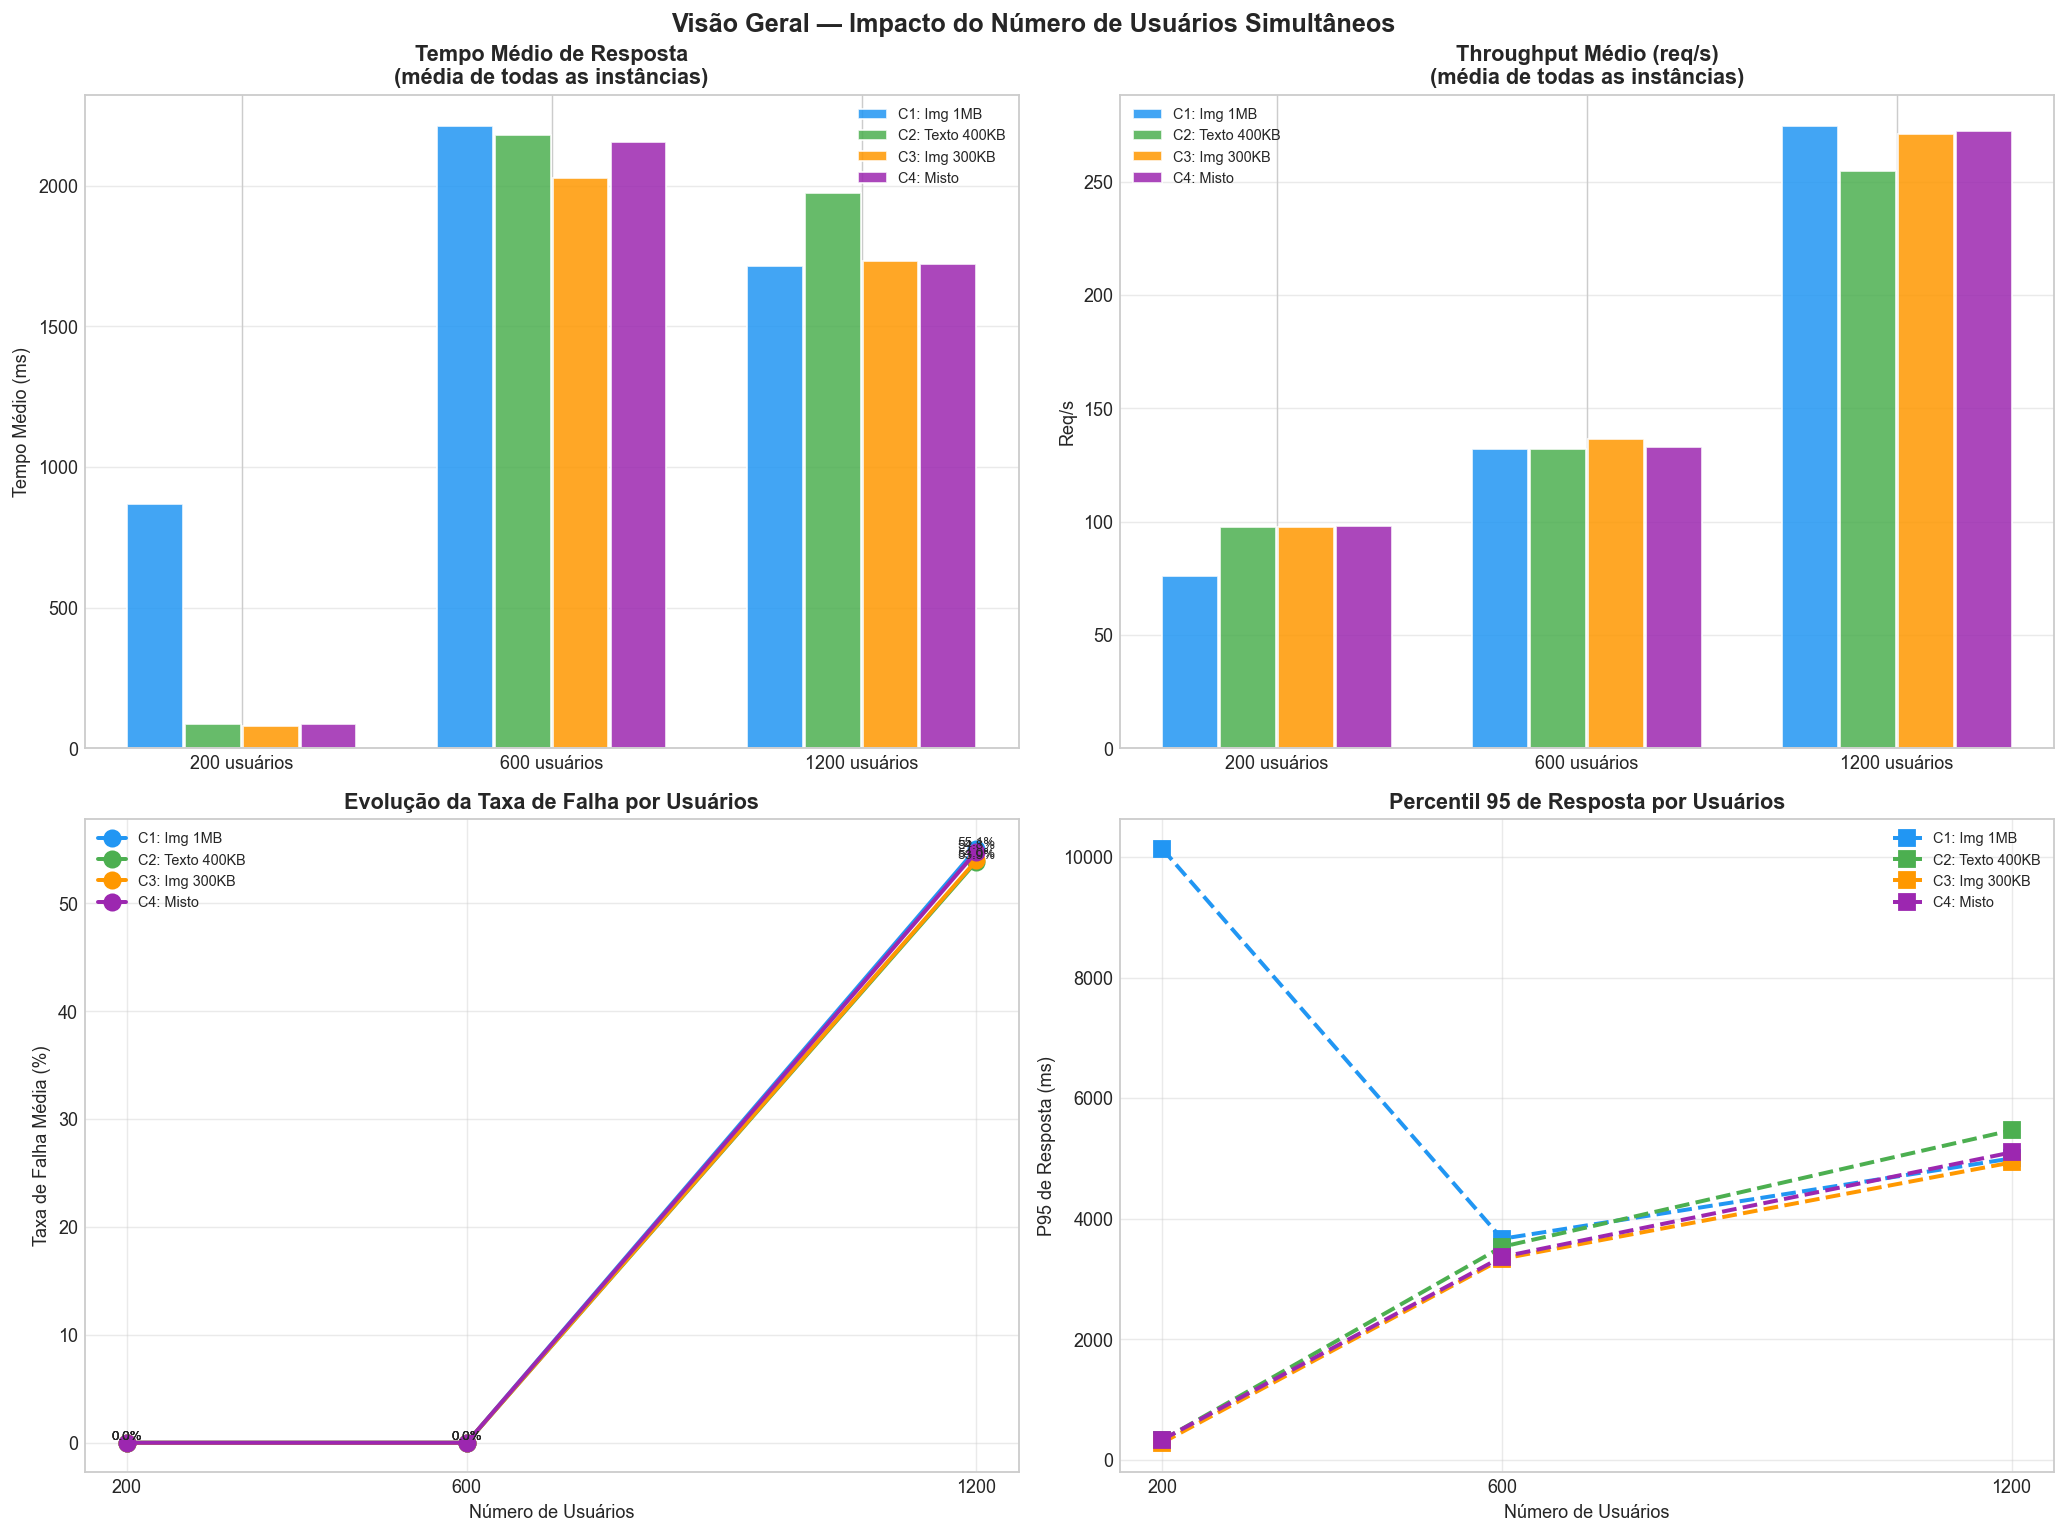

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visão Geral — Impacto do Número de Usuários Simultâneos',
             fontsize=14, fontweight='bold')

x_users = np.arange(len(USERS))
w       = 0.18
offsets = np.linspace(-0.28, 0.28, len(SCENARIOS))

def user_agg(sc, u, metric):
    s = df_all[(df_all['cenario'] == sc) & (df_all['users'] == u)]
    return s[metric].mean() if len(s) > 0 else 0

# (0,0) — Tempo médio de resposta
ax = axes[0, 0]
for sc, off in zip(SCENARIOS, offsets):
    vals = [user_agg(sc, u, 'avg_response_time') for u in USERS]
    ax.bar(x_users + off, vals, w, label=SCENARIO_LABELS[sc],
           color=SCENARIO_COLORS[sc], alpha=0.85, edgecolor='white')
ax.set_xticks(x_users)
ax.set_xticklabels([f'{u} usuários' for u in USERS])
ax.set_ylabel('Tempo Médio (ms)')
ax.set_title('Tempo Médio de Resposta\n(média de todas as instâncias)')
ax.legend(); ax.grid(axis='y', alpha=0.4); ax.set_ylim(bottom=0)

# (0,1) — Throughput
ax = axes[0, 1]
for sc, off in zip(SCENARIOS, offsets):
    vals = [user_agg(sc, u, 'requests_per_s') for u in USERS]
    ax.bar(x_users + off, vals, w, label=SCENARIO_LABELS[sc],
           color=SCENARIO_COLORS[sc], alpha=0.85, edgecolor='white')
ax.set_xticks(x_users)
ax.set_xticklabels([f'{u} usuários' for u in USERS])
ax.set_ylabel('Req/s')
ax.set_title('Throughput Médio (req/s)\n(média de todas as instâncias)')
ax.legend(); ax.grid(axis='y', alpha=0.4); ax.set_ylim(bottom=0)

# (1,0) — Taxa de falha (linha)
ax = axes[1, 0]
for sc in SCENARIOS:
    vals = [user_agg(sc, u, 'failure_rate') for u in USERS]
    ax.plot(USERS, vals, 'o-', label=SCENARIO_LABELS[sc],
            color=SCENARIO_COLORS[sc], linewidth=2.2, markersize=9)
    for xi, yi in zip(USERS, vals):
        ax.text(xi, yi + 0.3, f'{yi:.1f}%', ha='center', fontsize=7.5)
ax.set_xticks(USERS)
ax.set_xlabel('Número de Usuários')
ax.set_ylabel('Taxa de Falha Média (%)')
ax.set_title('Evolução da Taxa de Falha por Usuários')
ax.legend(); ax.grid(alpha=0.4)

# (1,1) — P95 (linha)
ax = axes[1, 1]
for sc in SCENARIOS:
    vals = [user_agg(sc, u, 'p95') for u in USERS]
    ax.plot(USERS, vals, 's--', label=SCENARIO_LABELS[sc],
            color=SCENARIO_COLORS[sc], linewidth=2.2, markersize=9)
ax.set_xticks(USERS)
ax.set_xlabel('Número de Usuários')
ax.set_ylabel('P95 de Resposta (ms)')
ax.set_title('Percentil 95 de Resposta por Usuários')
ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('resultados/grafico_geralzao_usuarios.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 7. Bônus — Heatmap de Tempo de Resposta
Mapa de calor mostrando o **tempo médio de resposta** para cada combinação  
instâncias × usuários, separado por cenário.


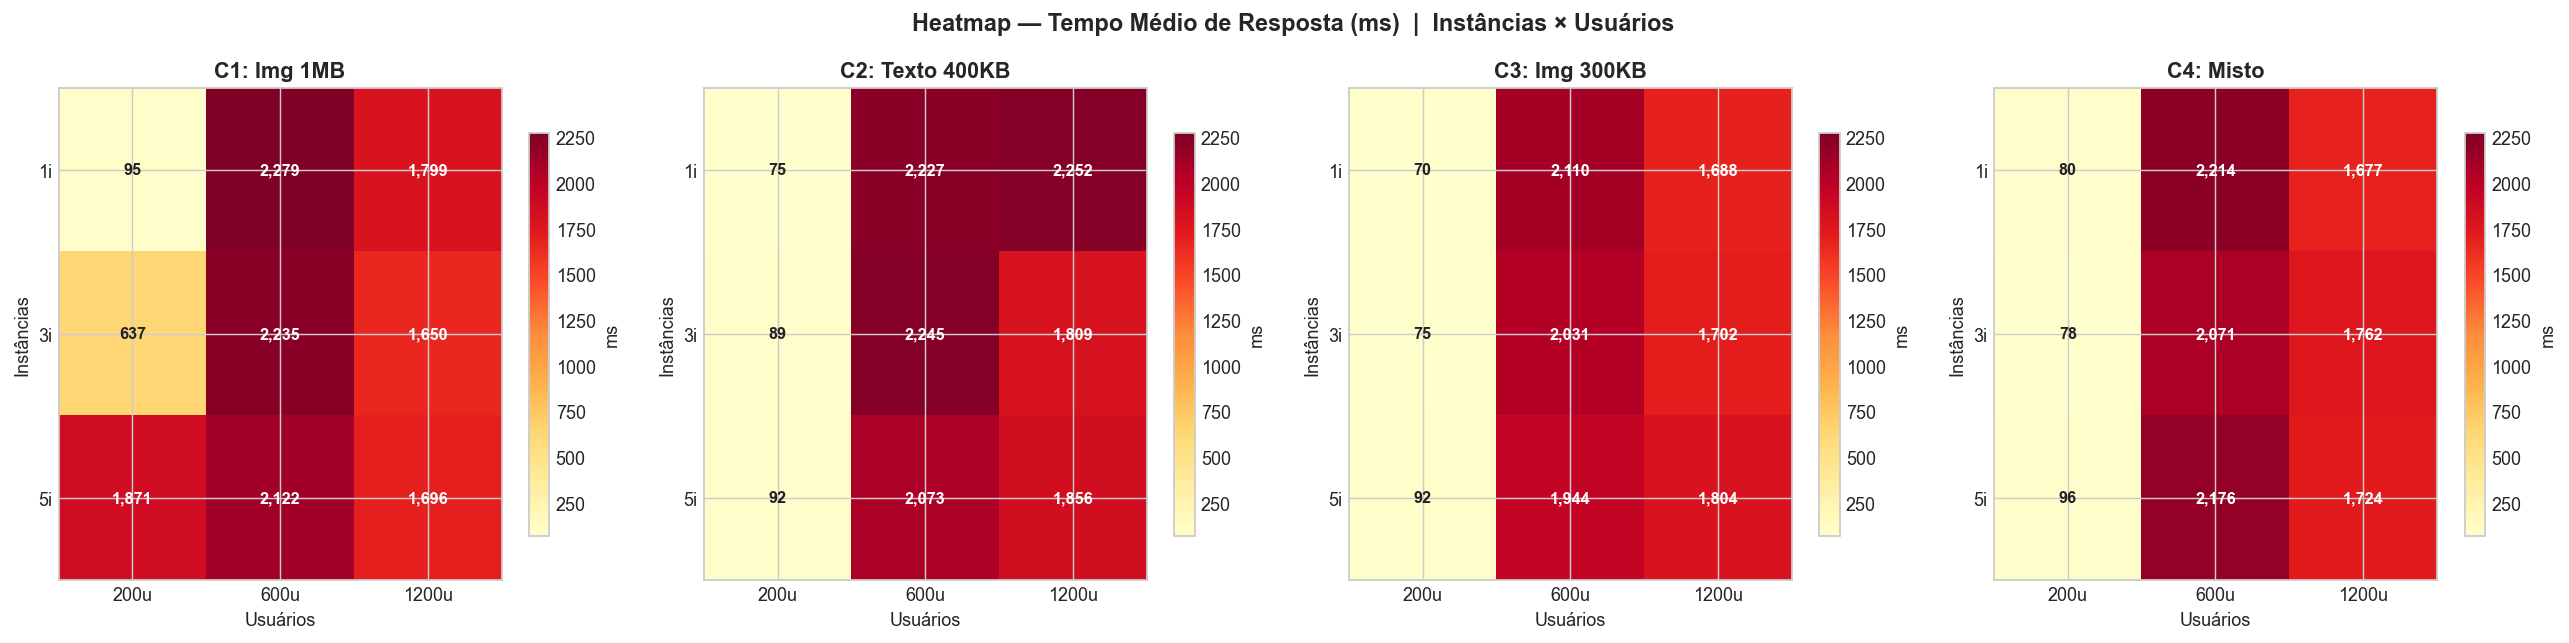

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Heatmap — Tempo Médio de Resposta (ms)  |  Instâncias × Usuários',
             fontsize=13, fontweight='bold')

# Normalização global para escala de cor consistente
vmin = df_all['avg_response_time'].min()
vmax = df_all['avg_response_time'].max()

for ax, sc in zip(axes, SCENARIOS):
    matrix = np.zeros((len(INSTANCES), len(USERS)))
    for i, inst in enumerate(INSTANCES):
        for j, u in enumerate(USERS):
            sub = df_all[
                (df_all['cenario'] == sc) &
                (df_all['instances'] == inst) &
                (df_all['users'] == u)
            ]
            matrix[i, j] = sub['avg_response_time'].values[0] if len(sub) > 0 else np.nan

    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.82, label='ms')

    ax.set_xticks(range(len(USERS)))
    ax.set_yticks(range(len(INSTANCES)))
    ax.set_xticklabels([f'{u}u' for u in USERS])
    ax.set_yticklabels([f'{i}i' for i in INSTANCES])
    ax.set_xlabel('Usuários')
    ax.set_ylabel('Instâncias')
    ax.set_title(SCENARIO_LABELS[sc])

    for i in range(len(INSTANCES)):
        for j in range(len(USERS)):
            val = matrix[i, j]
            if not np.isnan(val):
                threshold = vmin + (vmax - vmin) * 0.55
                txt_color = 'white' if val > threshold else '#222'
                ax.text(j, i, f'{val:,.0f}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=txt_color)

plt.tight_layout()
plt.savefig('resultados/grafico_heatmap_resposta.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 8. Bônus — Distribuição de Percentis de Resposta
Comparação dos percentis **P50, P90, P95 e P99** por cenário e número de instâncias  
(média de todas as cargas de usuários).


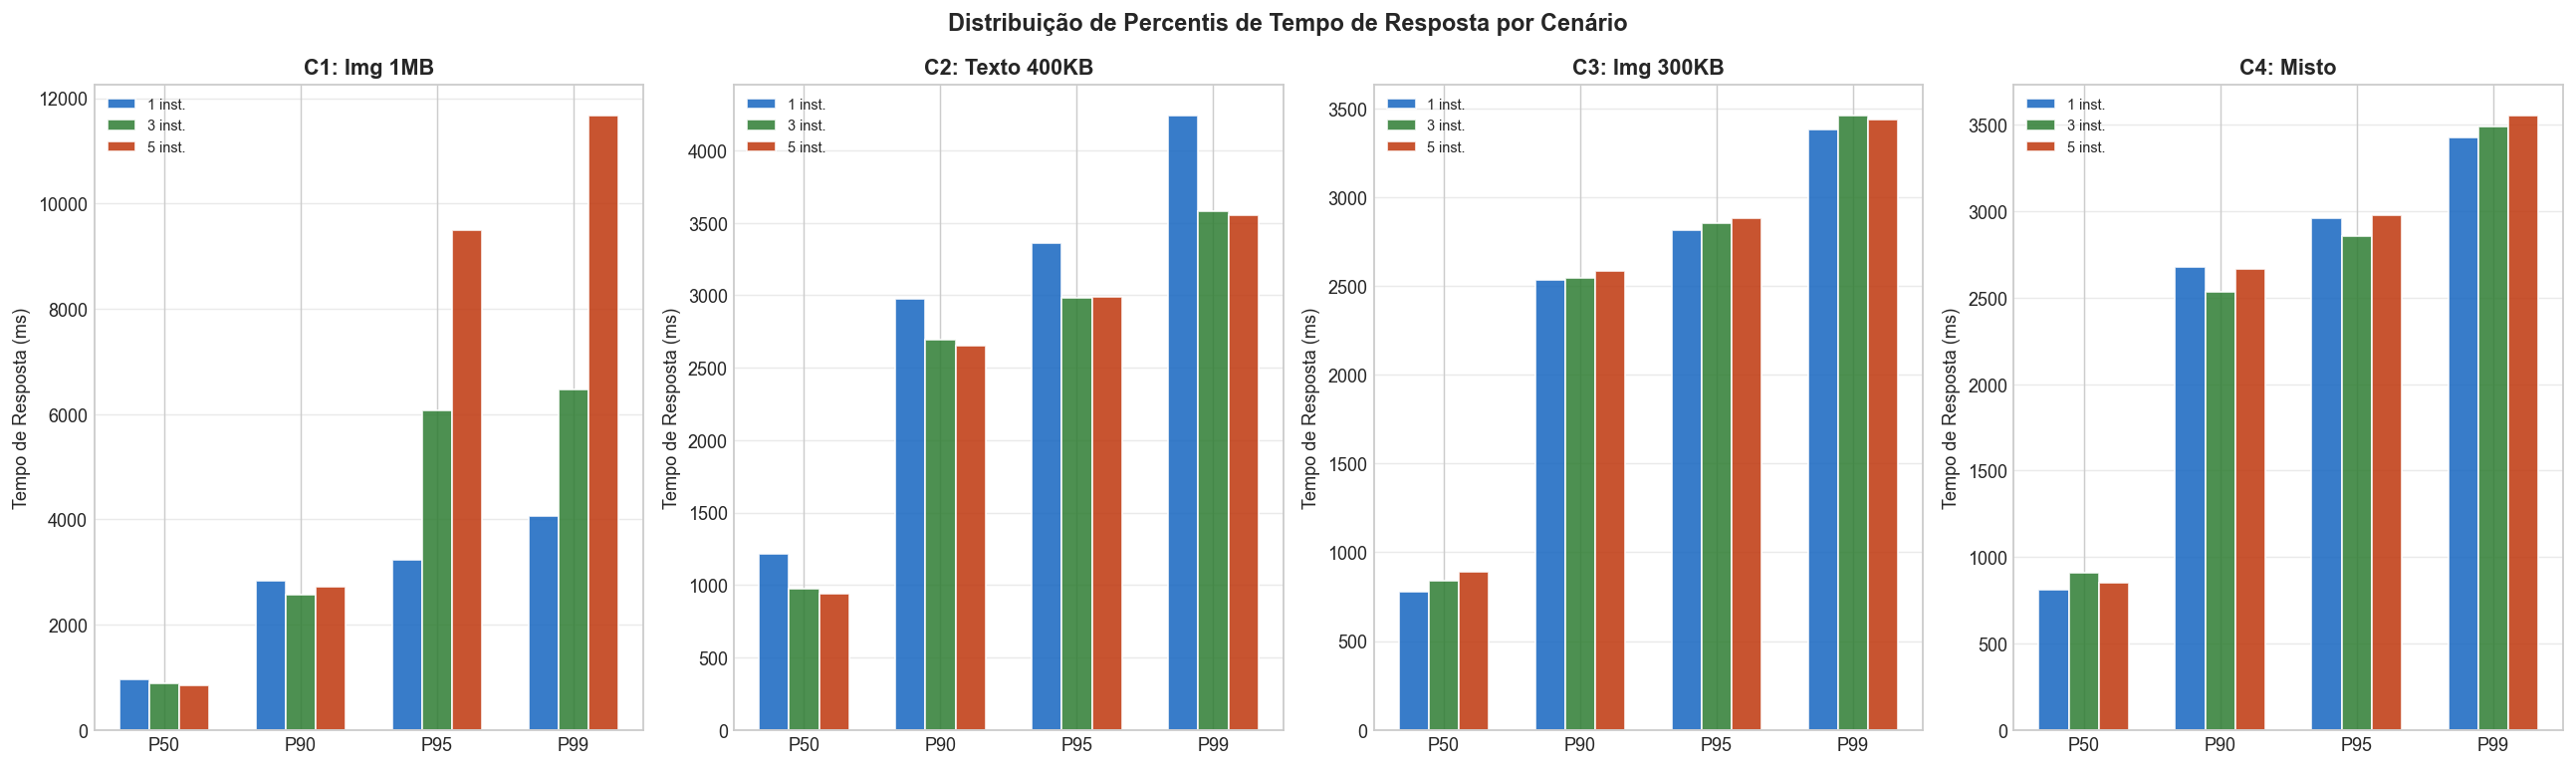

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Distribuição de Percentis de Tempo de Resposta por Cenário',
             fontsize=13, fontweight='bold')

PERC_COLS   = ['median_response_time', 'p90', 'p95', 'p99']
PERC_LABELS = ['P50', 'P90', 'P95', 'P99']
x_p = np.arange(len(PERC_COLS))
w   = 0.22
offsets = np.linspace(-(len(INSTANCES) - 1) / 2 * w, (len(INSTANCES) - 1) / 2 * w, len(INSTANCES))

for ax, sc in zip(axes, SCENARIOS):
    for inst, off in zip(INSTANCES, offsets):
        sub = df_all[(df_all['cenario'] == sc) & (df_all['instances'] == inst)]
        vals = [sub[p].mean() for p in PERC_COLS]
        color = INST_COLORS[inst]
        ax.bar(x_p + off, vals, w, label=f'{inst} inst.',
               color=color, alpha=0.85, edgecolor='white')

    ax.set_xticks(x_p)
    ax.set_xticklabels(PERC_LABELS)
    ax.set_title(SCENARIO_LABELS[sc])
    ax.set_ylabel('Tempo de Resposta (ms)')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('resultados/grafico_percentis.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 9. Bônus — Curva de Throughput × Carga
Como o **throughput (req/s)** evolui conforme a carga aumenta, separado por instâncias  
(revela o ponto de saturação do sistema).


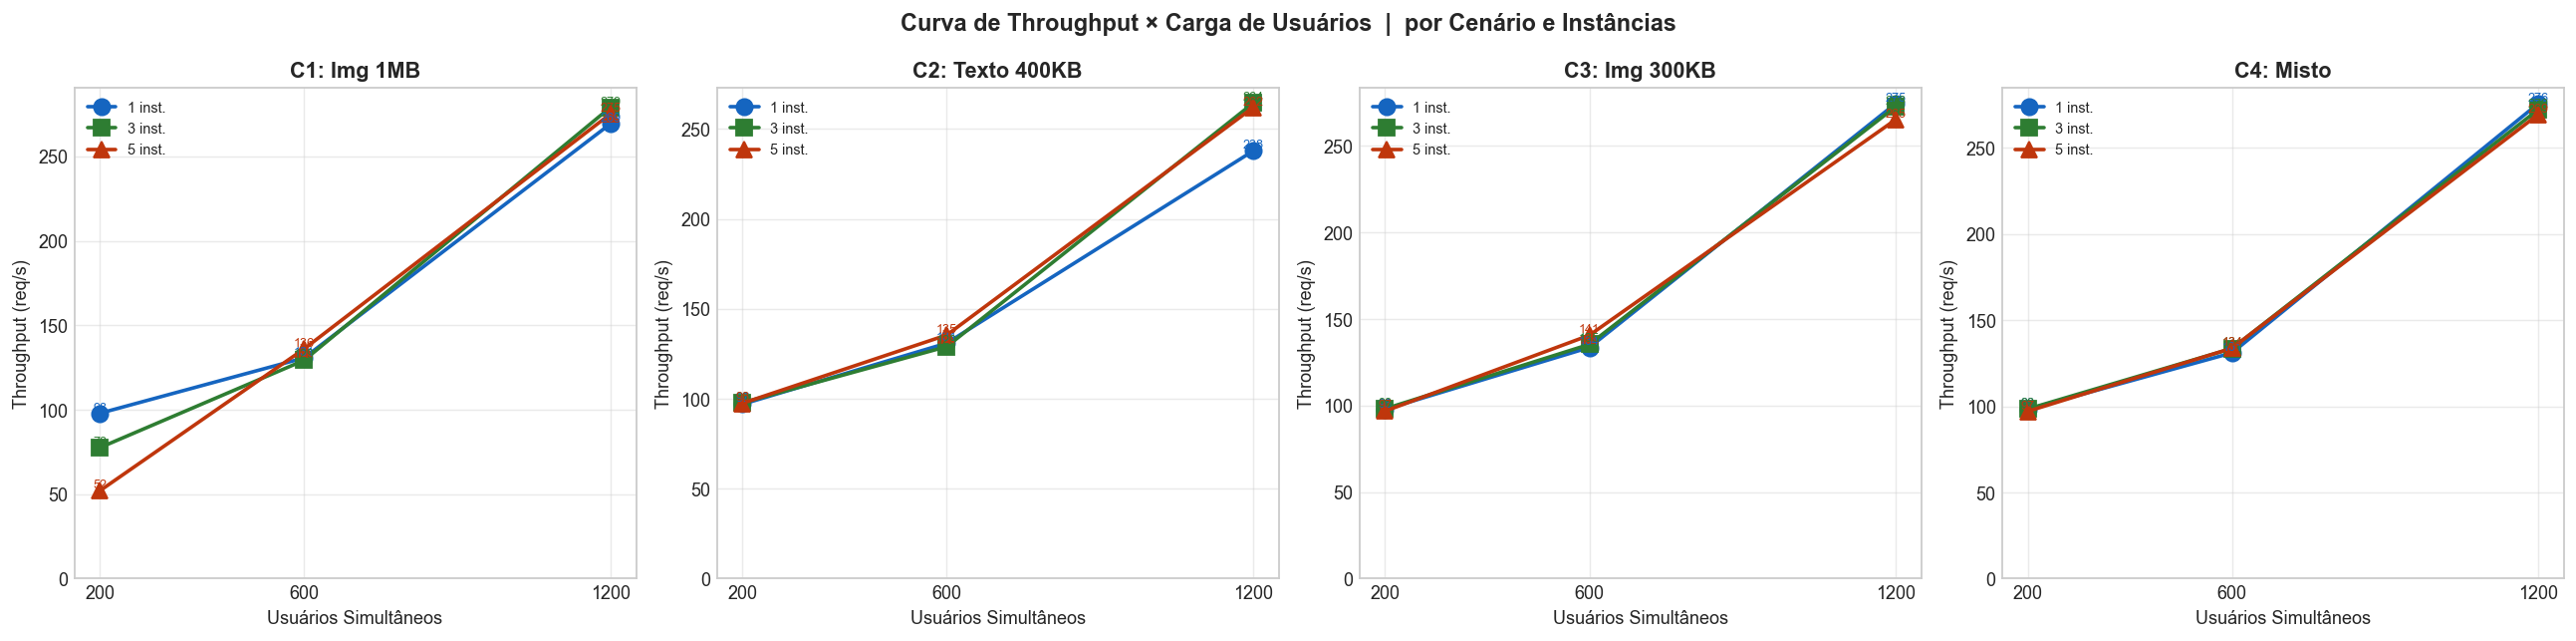

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Curva de Throughput × Carga de Usuários  |  por Cenário e Instâncias',
             fontsize=13, fontweight='bold')

markers = {1: 'o', 3: 's', 5: '^'}

for ax, sc in zip(axes, SCENARIOS):
    for inst in INSTANCES:
        sub = df_all[(df_all['cenario'] == sc) & (df_all['instances'] == inst)].sort_values('users')
        ax.plot(
            sub['users'], sub['requests_per_s'],
            marker=markers[inst], linestyle='-',
            color=INST_COLORS[inst], linewidth=2, markersize=9,
            label=f'{inst} inst.'
        )
        for _, r in sub.iterrows():
            ax.text(r['users'], r['requests_per_s'] + 1.5,
                    f"{r['requests_per_s']:.0f}",
                    ha='center', fontsize=7, color=INST_COLORS[inst])

    ax.set_xticks(USERS)
    ax.set_xlabel('Usuários Simultâneos')
    ax.set_ylabel('Throughput (req/s)')
    ax.set_title(SCENARIO_LABELS[sc])
    ax.legend()
    ax.grid(alpha=0.4)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('resultados/grafico_curva_throughput.png', bbox_inches='tight', dpi=130)
plt.show()


---
## 10. Bônus — Tabela-Resumo de Métricas Agregadas


In [22]:
summary = (
    df_all
    .groupby(['cenario', 'instances', 'users'])
    [['request_count', 'failure_rate', 'avg_response_time', 'p95', 'p99', 'requests_per_s']]
    .first()
    .rename(columns={
        'request_count'    : 'Requisições',
        'failure_rate'     : 'Falha (%)',
        'avg_response_time': 'Avg RT (ms)',
        'p95'              : 'P95 (ms)',
        'p99'              : 'P99 (ms)',
        'requests_per_s'   : 'Req/s',
    })
)

summary['Falha (%)']   = summary['Falha (%)'].round(2)
summary['Avg RT (ms)'] = summary['Avg RT (ms)'].round(1)
summary['P95 (ms)']    = summary['P95 (ms)'].astype(int)
summary['P99 (ms)']    = summary['P99 (ms)'].astype(int)
summary['Req/s']       = summary['Req/s'].round(1)

summary.index.names = ['Cenário', 'Instâncias', 'Usuários']

try:
    from IPython.display import display
    display(
        summary.style
        .background_gradient(subset=['Falha (%)'],     cmap='Reds')
        .background_gradient(subset=['Avg RT (ms)'],   cmap='YlOrRd')
        .background_gradient(subset=['Req/s'],         cmap='Greens')
        .format({'Falha (%)': '{:.2f}', 'Req/s': '{:.1f}'})
    )
except Exception:
    print(summary.to_string())
